# Part A: Conceptual Understanding

## 1. What is Logistic Regression and why is it suitable for classification?

Logistic Regression is a supervised machine learning algorithm mainly used for classification problems. It calculates the probability of an observation belonging to a particular class and then assigns it to a class based on a threshold. In this project, it is suitable because the target variable `Risk Status` contains two classes: 0 for Low Risk and 1 for High Risk. It also provides a simple and useful baseline model for comparing other classification algorithms.

---

## 2. Explain classification performance metrics and why accuracy alone is insufficient.

Accuracy measures the percentage of total predictions that are correct. However, accuracy alone can be misleading when the dataset is imbalanced because a model can get high accuracy by mainly predicting the majority class. Therefore, Precision, Recall, F1-Score and AUC-ROC are also important for evaluating the model. In this project, Recall is especially important because we want to correctly identify High Risk customers.

---

## 3. Define Type-I Error and Type-II Error in the context of risk prediction.

Type-I Error, also called a False Positive, occurs when a customer who is actually Low Risk is incorrectly predicted as High Risk. Type-II Error, also called a False Negative, occurs when a customer who is actually High Risk is incorrectly predicted as Low Risk. In this banking risk prediction problem, Type-II Error is more serious because the system may fail to identify a genuinely High Risk customer.

    
---

## 4. Explain Precision, Recall, F1-Score, TPR, and FPR.

Precision measures how many customers predicted as High Risk are actually High Risk. Recall measures how many of the actual High Risk customers are correctly identified by the model. F1-Score is the harmonic mean of Precision and Recall and gives a balanced measure of both. TPR (True Positive Rate) is the same as Recall, while FPR (False Positive Rate) measures the proportion of Low Risk customers incorrectly classified as High Risk.

---

## 5. What is AUC-ROC and how does it help in evaluating classifiers?

ROC (Receiver Operating Characteristic) is a curve that shows the relationship between True Positive Rate and False Positive Rate at different classification thresholds. AUC (Area Under the Curve) summarizes the performance of the ROC curve into a single value. A higher AUC generally indicates that the model has a better ability to distinguish between Low Risk and High Risk customers. It is useful when comparing different classification models.

---

## 6. Why does imbalanced data create problems in classification models?

Imbalanced data occurs when one class has significantly more observations than another class. In this project, if Low Risk customers are much more common than High Risk customers, the model may become biased toward predicting Low Risk. As a result, it may achieve high accuracy while missing many High Risk customers. Therefore, techniques such as Under-Sampling, Over-Sampling, SMOTE and ADASYN can be used to improve the model's ability to identify the minority class.

In [8]:
# ============================================================
# COMPLETE PROJECT — ALL REQUIRED IMPORTS
# ============================================================

# ------------------------------------------------------------
# 1. DATA HANDLING
# ------------------------------------------------------------

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 2. VISUALIZATION
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# 3. DATA PREPROCESSING
# ------------------------------------------------------------

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import (
    SimpleImputer,
    KNNImputer
)


# ------------------------------------------------------------
# 4. PIPELINES
# ------------------------------------------------------------

from sklearn.pipeline import Pipeline


# ------------------------------------------------------------
# 5. TRAIN-TEST SPLIT & CROSS VALIDATION
# ------------------------------------------------------------

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)


# ------------------------------------------------------------
# 6. MACHINE LEARNING MODELS
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier


# ------------------------------------------------------------
# 7. IMBALANCED DATA HANDLING
# ------------------------------------------------------------

from imblearn.under_sampling import (
    RandomUnderSampler
)

from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    ADASYN
)


# ------------------------------------------------------------
# 8. MODEL EVALUATION
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)


# ------------------------------------------------------------
# 9. MODEL INSPECTION
# ------------------------------------------------------------

from sklearn.inspection import permutation_importance


# ------------------------------------------------------------
# 10. DISPLAY
# ------------------------------------------------------------

from IPython.display import display


# ------------------------------------------------------------
# 11. WARNINGS
# ------------------------------------------------------------

import warnings

warnings.filterwarnings("ignore")


# ============================================================
# IMPORT CHECK
# ============================================================

print("=" * 60)
print("ALL REQUIRED LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)

ALL REQUIRED LIBRARIES IMPORTED SUCCESSFULLY


STEP 1 — LOADING DATASET

Dataset loaded successfully.
Rows    : 4600
Columns : 19

STEP 2 — INITIAL DATASET PREVIEW


,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0



STEP 3 — DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,4600.0,NaN,NaN,NaN,502300.5,1328.049949,500001.0,501150.75,502300.5,503450.25,504600.0
age,4460.0,NaN,NaN,NaN,36.360314,10.670375,18.0,28.0,36.0,44.0,75.0
gender,4600,3,Male,2358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,4498,5,South,1057,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,4456,5,Salaried,2354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_income_inr,4434.0,NaN,NaN,NaN,41753.518268,17740.750972,15000.0,28980.0,38932.5,51282.5,163002.0
credit_score,4384.0,NaN,NaN,NaN,677.784443,64.888787,405.0,638.0,682.0,721.25,850.0
credit_utilization_ratio,4453.0,NaN,NaN,NaN,0.394721,0.205771,0.002,0.232,0.37,0.531,0.978
missed_payments_12m,4600.0,NaN,NaN,NaN,0.92413,1.300018,0.0,0.0,1.0,1.0,10.0
avg_late_payment_days,4600.0,NaN,NaN,NaN,5.538696,5.624891,0.1,2.1,3.9,6.6,47.1



STEP 5 — COLUMN INFORMATION


,Column,Data Type,Missing Values,Missing (%),Unique Values
customer_id,customer_id,int64,0,0.00,4600
age,age,float64,140,3.04,55
gender,gender,object,0,0.00,3
region,region,object,102,2.22,5
employment_type,employment_type,object,144,3.13,5
annual_income_inr,annual_income_inr,float64,166,3.61,4188
credit_score,credit_score,float64,216,4.70,356
credit_utilization_ratio,credit_utilization_ratio,float64,147,3.20,878
missed_payments_12m,missed_payments_12m,int64,0,0.00,11
avg_late_payment_days,avg_late_payment_days,float64,0,0.00,300



STEP 6 — DUPLICATE RECORD CHECK

Number of duplicate records: 0
✓ No duplicate records found.

STEP 7 — MISSING VALUE ANALYSIS


,Missing Values,Percentage (%)
credit_score,216,4.70
annual_income_inr,166,3.61
credit_utilization_ratio,147,3.20
employment_type,144,3.13
age,140,3.04
monthly_spend_inr,129,2.80
region,102,2.22
gender,0,0.00
customer_id,0,0.00
avg_late_payment_days,0,0.00



Generating missing-value visualization...


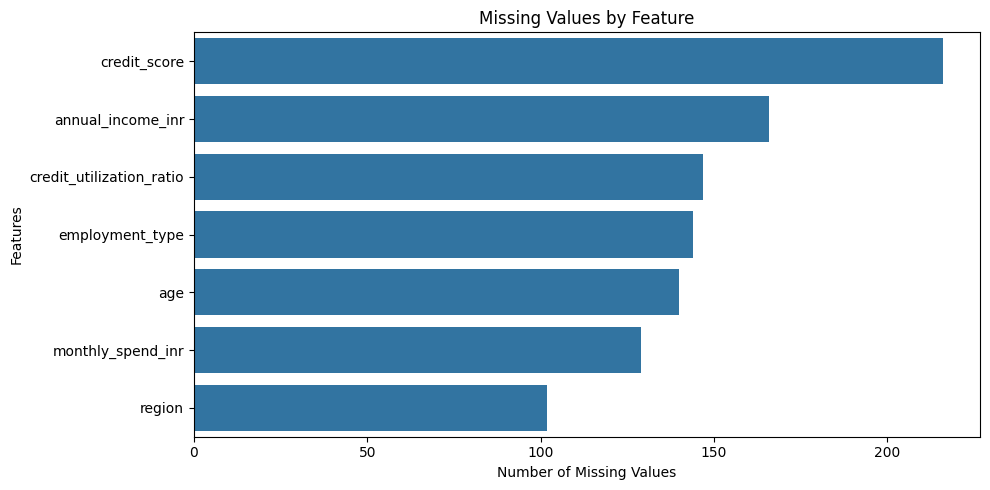


STEP 8 — TARGET VARIABLE IDENTIFICATION

Target Variable      : risk_status
Number of Input Features : 18

STEP 9 — TARGET VARIABLE ANALYSIS


,Count,Percentage (%)
risk_status,,
0,4043,87.89
1,557,12.11



Target Classes: [np.int64(0), np.int64(1)]
✓ Target variable is binary.


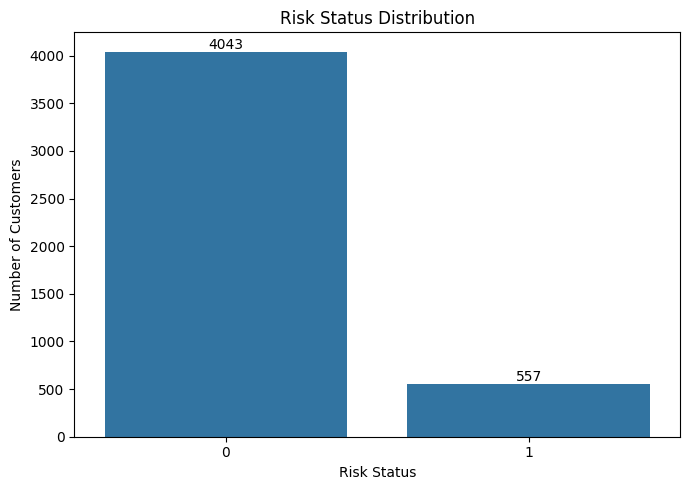


Class Distribution Analysis:
⚠ Dataset is imbalanced. Minority class represents approximately 12.11% of the data.

STEP 10 — FEATURE TYPE IDENTIFICATION

Numerical Features:
 - customer_id
 - age
 - annual_income_inr
 - credit_score
 - credit_utilization_ratio
 - missed_payments_12m
 - avg_late_payment_days
 - monthly_transaction_count
 - monthly_spend_inr
 - cash_advance_count_6m
 - complaints_last_6m
 - failed_login_attempts_3m
 - account_tenure_months
 - debt_balance_inr

Categorical Features:
 - gender
 - region
 - employment_type
 - last_transaction_date

STEP 11 — DATE FEATURE ENGINEERING

Original date feature:
last_transaction_date

Date range:
Minimum: 2025-09-03 00:00:00
Maximum: 2025-12-01 00:00:00

✓ Date column successfully converted to datetime.

STEP 12 — IDENTIFIER HANDLING

✓ customer_id removed because it is an identifier and does not represent customer behavior.

STEP 13 — TRAIN-TEST SPLIT

Training samples : 3680
Testing samples  : 920

Training percentage: 80.0 %


,Original,Training,Testing
risk_status,,,
0,0.879,0.879,0.879
1,0.121,0.121,0.121



✓ Stratified split maintains approximately the same class proportions.

STEP 15 — DATE FEATURE TRANSFORMATION

Reference date: 2025-12-01

✓ last_transaction_date converted to days_since_last_transaction.
✓ Reference date calculated using training data only.

STEP 16 — FINAL FEATURE TYPES

Numerical Features:
['age', 'annual_income_inr', 'credit_score', 'credit_utilization_ratio', 'missed_payments_12m', 'avg_late_payment_days', 'monthly_transaction_count', 'monthly_spend_inr', 'cash_advance_count_6m', 'complaints_last_6m', 'failed_login_attempts_3m', 'account_tenure_months', 'debt_balance_inr', 'days_since_last_transaction']

Categorical Features:
['gender', 'region', 'employment_type']

Number of numerical features: 14
Number of categorical features: 3

STEP 17 — MISSING VALUE IMPUTATION

Applying scaled KNN imputation...
✓ Numerical missing values handled using scaled KNN imputation.

Applying most-frequent imputation...
✓ Categorical missing values handled using training-data mode.

,Feature,Data Type,Missing in Train,Missing in Test
age,age,float64,0,0
gender,gender,object,0,0
region,region,object,0,0
employment_type,employment_type,object,0,0
annual_income_inr,annual_income_inr,float64,0,0
credit_score,credit_score,float64,0,0
credit_utilization_ratio,credit_utilization_ratio,float64,0,0
missed_payments_12m,missed_payments_12m,float64,0,0
avg_late_payment_days,avg_late_payment_days,float64,0,0
monthly_transaction_count,monthly_transaction_count,float64,0,0



PART B COMPLETED SUCCESSFULLY

Original dataset       : (4600, 19)
Training data          : (3680, 17)
Testing data           : (920, 17)

Target variable        : risk_status
Input features         : 17
Numerical features     : 14
Categorical features   : 3

Training samples       : 3680
Testing samples        : 920

Training missing values: 0
Testing missing values : 0

Duplicate records      : 0

✓ Dataset understanding completed.
✓ Data quality checked.
✓ Target variable identified.
✓ Class distribution analysed.
✓ Identifier removed.
✓ Date feature engineered.
✓ Stratified train-test split completed.
✓ Missing values imputed without data leakage.
✓ Final dataset validated.


In [9]:
# ============================================================
# PART B — DATASET UNDERSTANDING & PREPARATION
# ============================================================


# ============================================================
# 1. LOAD DATASET
# ============================================================

print("=" * 70)
print("STEP 1 — LOADING DATASET")
print("=" * 70)

url = "https://docs.google.com/spreadsheets/d/1W6Qqz-Z5pud61L8erxgjwPD22RZe01161a_OrJKkqjE/export?format=csv"

df = pd.read_csv(url)

print("\nDataset loaded successfully.")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")


# ============================================================
# 2. INITIAL DATASET PREVIEW
# ============================================================

print("\n" + "=" * 70)
print("STEP 2 — INITIAL DATASET PREVIEW")
print("=" * 70)

display(df.head())


# ============================================================
# 3. DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 3 — DATASET INFORMATION")
print("=" * 70)

df.info()


# ============================================================
# 4. STATISTICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STEP 4 — STATISTICAL SUMMARY")
print("=" * 70)

display(df.describe(include="all").T)


# ============================================================
# 5. COLUMN INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 5 — COLUMN INFORMATION")
print("=" * 70)

column_information = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique()
})

display(column_information)


# ============================================================
# 6. CHECK DUPLICATE RECORDS
# ============================================================

print("\n" + "=" * 70)
print("STEP 6 — DUPLICATE RECORD CHECK")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print(f"\nNumber of duplicate records: {duplicate_count}")

if duplicate_count == 0:
    print("✓ No duplicate records found.")
else:
    print("⚠ Duplicate records found.")


# ============================================================
# 7. MISSING VALUE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("STEP 7 — MISSING VALUE ANALYSIS")
print("=" * 70)

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (
        missing_values / len(df) * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    "Missing Values",
    ascending=False
)

display(missing_summary)


# ============================================================
# 8. VISUALIZE MISSING VALUES
# ============================================================

print("\nGenerating missing-value visualization...")

missing_plot = missing_summary[
    missing_summary["Missing Values"] > 0
]

if len(missing_plot) > 0:

    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=missing_plot["Missing Values"],
        y=missing_plot.index
    )

    plt.title("Missing Values by Feature")
    plt.xlabel("Number of Missing Values")
    plt.ylabel("Features")

    plt.tight_layout()
    plt.show()

else:
    print("✓ No missing values found.")


# ============================================================
# 9. IDENTIFY TARGET VARIABLE
# ============================================================

print("\n" + "=" * 70)
print("STEP 8 — TARGET VARIABLE IDENTIFICATION")
print("=" * 70)

target_column = "risk_status"

X = df.drop(columns=[target_column])
y = df[target_column]

print(f"\nTarget Variable      : {target_column}")
print(f"Number of Input Features : {X.shape[1]}")


# ============================================================
# 10. TARGET VARIABLE VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 9 — TARGET VARIABLE ANALYSIS")
print("=" * 70)

class_counts = y.value_counts().sort_index()

class_percentages = (
    y.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percentages
})

display(class_distribution)


# Check target classes

print("\nTarget Classes:", sorted(y.unique()))

if set(y.unique()) == {0, 1}:
    print("✓ Target variable is binary.")
else:
    print("⚠ Target variable contains unexpected classes.")


# ============================================================
# 11. VISUALIZE TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x=target_column
)

plt.title("Risk Status Distribution")
plt.xlabel("Risk Status")
plt.ylabel("Number of Customers")

# Add values on bars

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


# ============================================================
# 12. CHECK CLASS IMBALANCE
# ============================================================

minority_percentage = class_percentages.min()

print("\nClass Distribution Analysis:")

if minority_percentage < 20:
    print(
        f"⚠ Dataset is imbalanced. "
        f"Minority class represents approximately "
        f"{minority_percentage}% of the data."
    )
else:
    print("✓ Classes are reasonably balanced.")


# ============================================================
# 13. IDENTIFY FEATURE TYPES
# ============================================================

print("\n" + "=" * 70)
print("STEP 10 — FEATURE TYPE IDENTIFICATION")
print("=" * 70)

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumerical Features:")
for feature in numerical_features:
    print(" -", feature)

print("\nCategorical Features:")
for feature in categorical_features:
    print(" -", feature)


# ============================================================
# 14. HANDLE DATE FEATURE
# ============================================================

print("\n" + "=" * 70)
print("STEP 11 — DATE FEATURE ENGINEERING")
print("=" * 70)

if "last_transaction_date" in X.columns:

    # Convert date column into datetime format
    X["last_transaction_date"] = pd.to_datetime(
        X["last_transaction_date"],
        errors="coerce"
    )

    print("\nOriginal date feature:")
    print("last_transaction_date")

    print("\nDate range:")
    print("Minimum:", X["last_transaction_date"].min())
    print("Maximum:", X["last_transaction_date"].max())

    # Keep original date temporarily.
    # The final reference date will be obtained
    # from the training data after splitting.

    print("\n✓ Date column successfully converted to datetime.")


# ============================================================
# 15. REMOVE ID FEATURE
# ============================================================

print("\n" + "=" * 70)
print("STEP 12 — IDENTIFIER HANDLING")
print("=" * 70)

if "customer_id" in X.columns:

    X = X.drop(columns=["customer_id"])

    print(
        "\n✓ customer_id removed because it is an identifier "
        "and does not represent customer behavior."
    )


# ============================================================
# 16. TRAIN-TEST SPLIT
# ============================================================

print("\n" + "=" * 70)
print("STEP 13 — TRAIN-TEST SPLIT")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Important:
# .copy() prevents SettingWithCopyWarning

X_train = X_train.copy()
X_test = X_test.copy()

print("\nTraining samples :", len(X_train))
print("Testing samples  :", len(X_test))

print("\nTraining percentage:",
      round(len(X_train) / len(X) * 100, 2), "%")

print("Testing percentage :",
      round(len(X_test) / len(X) * 100, 2), "%")


# ============================================================
# 17. VERIFY STRATIFIED SPLIT
# ============================================================

print("\n" + "=" * 70)
print("STEP 14 — VERIFY STRATIFIED SPLIT")
print("=" * 70)

distribution_check = pd.DataFrame({

    "Original": y.value_counts(normalize=True),

    "Training": y_train.value_counts(normalize=True),

    "Testing": y_test.value_counts(normalize=True)

}).fillna(0).round(3)

display(distribution_check)

print(
    "\n✓ Stratified split maintains approximately "
    "the same class proportions."
)


# ============================================================
# 18. DATE FEATURE ENGINEERING AFTER SPLIT
# ============================================================

print("\n" + "=" * 70)
print("STEP 15 — DATE FEATURE TRANSFORMATION")
print("=" * 70)

if "last_transaction_date" in X_train.columns:

    # Use only TRAINING data to determine the reference date.
    # This prevents information leakage from the test set.

    reference_date = X_train["last_transaction_date"].max()

    print("\nReference date:", reference_date.date())

    X_train["days_since_last_transaction"] = (
        reference_date -
        X_train["last_transaction_date"]
    ).dt.days

    X_test["days_since_last_transaction"] = (
        reference_date -
        X_test["last_transaction_date"]
    ).dt.days

    # Remove original date column
    X_train.drop(
        columns=["last_transaction_date"],
        inplace=True
    )

    X_test.drop(
        columns=["last_transaction_date"],
        inplace=True
    )

    print(
        "\n✓ last_transaction_date converted to "
        "days_since_last_transaction."
    )

    print(
        "✓ Reference date calculated using training data only."
    )


# ============================================================
# 19. UPDATE FEATURE TYPES
# ============================================================

print("\n" + "=" * 70)
print("STEP 16 — FINAL FEATURE TYPES")
print("=" * 70)

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of numerical features:",
      len(numerical_features))

print("Number of categorical features:",
      len(categorical_features))


# ============================================================
# 20. MISSING VALUE IMPUTATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 17 — MISSING VALUE IMPUTATION")
print("=" * 70)


# ------------------------------------------------------------
# 20.1 NUMERICAL FEATURES
# ------------------------------------------------------------

if len(numerical_features) > 0:

    print("\nApplying scaled KNN imputation...")

    # KNN is distance-based.
    # Therefore, numerical features are scaled before
    # calculating nearest neighbours.

    scaler_for_knn = StandardScaler()

    X_train_num_scaled = scaler_for_knn.fit_transform(
        X_train[numerical_features]
    )

    X_test_num_scaled = scaler_for_knn.transform(
        X_test[numerical_features]
    )

    # KNN Imputer
    knn_imputer = KNNImputer(
        n_neighbors=5,
        weights="distance"
    )

    X_train_num_imputed = knn_imputer.fit_transform(
        X_train_num_scaled
    )

    X_test_num_imputed = knn_imputer.transform(
        X_test_num_scaled
    )

    # Convert values back to original scale
    X_train[numerical_features] = (
        scaler_for_knn.inverse_transform(
            X_train_num_imputed
        )
    )

    X_test[numerical_features] = (
        scaler_for_knn.inverse_transform(
            X_test_num_imputed
        )
    )

    print(
        "✓ Numerical missing values handled "
        "using scaled KNN imputation."
    )


# ------------------------------------------------------------
# 20.2 CATEGORICAL FEATURES
# ------------------------------------------------------------

if len(categorical_features) > 0:

    print("\nApplying most-frequent imputation...")

    for column in categorical_features:

        # Calculate mode using training data only
        most_frequent_value = X_train[column].mode()[0]

        X_train[column] = X_train[column].fillna(
            most_frequent_value
        )

        X_test[column] = X_test[column].fillna(
            most_frequent_value
        )

    print(
        "✓ Categorical missing values handled "
        "using training-data mode."
    )


print("\n✓ Missing value imputation completed.")


# ============================================================
# 21. VERIFY MISSING VALUES AFTER IMPUTATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 18 — POST-IMPUTATION VALIDATION")
print("=" * 70)

train_missing = X_train.isnull().sum()
test_missing = X_test.isnull().sum()

train_missing = train_missing[
    train_missing > 0
]

test_missing = test_missing[
    test_missing > 0
]


print("\nMissing Values in Training Data:")

if len(train_missing) == 0:
    print("✓ No missing values.")
else:
    display(train_missing)


print("\nMissing Values in Testing Data:")

if len(test_missing) == 0:
    print("✓ No missing values.")
else:
    display(test_missing)


# ============================================================
# 22. FINAL DATA SHAPE VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 19 — FINAL DATA VALIDATION")
print("=" * 70)

print("\nTraining data shape :", X_train.shape)
print("Testing data shape  :", X_test.shape)

print("\nTraining target shape :", y_train.shape)
print("Testing target shape  :", y_test.shape)


# Check whether train and test feature columns match

if list(X_train.columns) == list(X_test.columns):
    print("\n✓ Training and testing features match.")
else:
    print("\n⚠ Training and testing features do not match.")


# Check infinite values

train_infinite = np.isinf(
    X_train.select_dtypes(include=np.number)
).sum().sum()

test_infinite = np.isinf(
    X_test.select_dtypes(include=np.number)
).sum().sum()

print("\nInfinite values in training data :", train_infinite)
print("Infinite values in testing data  :", test_infinite)


# ============================================================
# 23. FINAL FEATURE SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STEP 20 — FINAL FEATURE SUMMARY")
print("=" * 70)

feature_summary = pd.DataFrame({
    "Feature": X_train.columns,
    "Data Type": X_train.dtypes.astype(str),
    "Missing in Train": X_train.isnull().sum().values,
    "Missing in Test": X_test.isnull().sum().values
})

display(feature_summary)


# ============================================================
# 24. FINAL PART B SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PART B COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"\nOriginal dataset       : {df.shape}")
print(f"Training data          : {X_train.shape}")
print(f"Testing data           : {X_test.shape}")

print(f"\nTarget variable        : {target_column}")
print(f"Input features         : {X_train.shape[1]}")

print(f"Numerical features     : {len(numerical_features)}")
print(f"Categorical features   : {len(categorical_features)}")

print(f"\nTraining samples       : {len(X_train)}")
print(f"Testing samples        : {len(X_test)}")

print(f"\nTraining missing values: {X_train.isnull().sum().sum()}")
print(f"Testing missing values : {X_test.isnull().sum().sum()}")

print(f"\nDuplicate records      : {duplicate_count}")

print("\n✓ Dataset understanding completed.")
print("✓ Data quality checked.")
print("✓ Target variable identified.")
print("✓ Class distribution analysed.")
print("✓ Identifier removed.")
print("✓ Date feature engineered.")
print("✓ Stratified train-test split completed.")
print("✓ Missing values imputed without data leakage.")
print("✓ Final dataset validated.")

PART C — LOGISTIC REGRESSION BASELINE

STEP 1 — DATA INFORMATION

Training Data Shape : (3680, 17)
Testing Data Shape  : (920, 17)

Training Target Distribution:
risk_status
0    3234
1     446
Name: count, dtype: int64

Testing Target Distribution:
risk_status
0    809
1    111
Name: count, dtype: int64

STEP 2 — DATA PREPROCESSING

Numerical features   : StandardScaler
Categorical features : OneHotEncoder

STEP 3 — LOGISTIC REGRESSION BASELINE

Model: Logistic Regression
Class Weight: None
Max Iterations: 2000

✓ Preprocessing and Logistic Regression pipeline created.

STEP 4 — MODEL TRAINING

✓ Logistic Regression model trained successfully.

STEP 5 — TEST SET PREDICTION

✓ Predictions generated successfully.

STEP 6 — BASELINE MODEL PERFORMANCE

Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000

STEP 7 — CLASSIFICATION REPORT
               precision    recall  f1-score   support

 Low Risk (0)       1.00      1.00      1.00       809
Hi

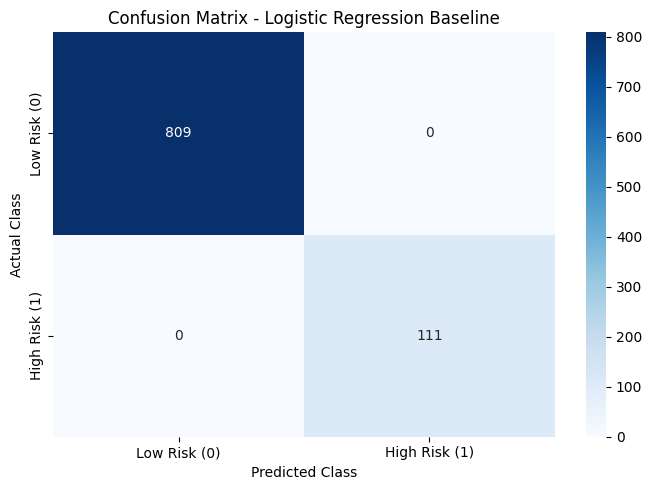


STEP 10 — ROC CURVE


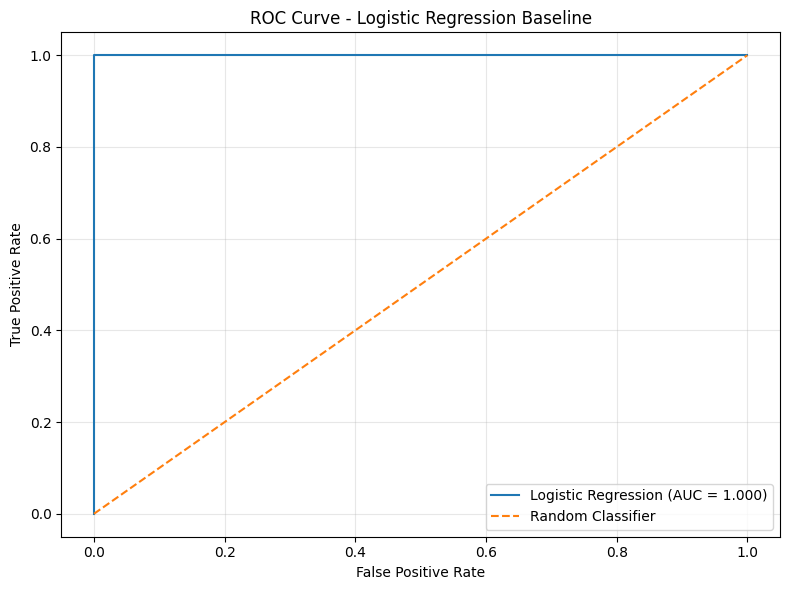


STEP 11 — TRAIN VS TEST PERFORMANCE


,Dataset,F1 Score
0,Training,0.9876
1,Testing,1.0000



The training and testing F1 scores can be compared to check whether the baseline model is generalizing well.

STEP 12 — BASELINE RESULTS SUMMARY


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Type-I Error (FP),Type-II Error (FN)
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0,0,0



PART C COMPLETED SUCCESSFULLY

Model              : Logistic Regression
Training samples   : 3680
Testing samples    : 920

Accuracy            : 1.0
Precision           : 1.0
Recall              : 1.0
F1 Score            : 1.0
ROC-AUC             : 1.0

Type-I Error (FP)   : 0
Type-II Error (FN) : 0

✓ Logistic Regression baseline created.
✓ Model trained successfully.
✓ Accuracy calculated.
✓ Precision calculated.
✓ Recall calculated.
✓ F1 Score calculated.
✓ ROC-AUC calculated.
✓ Confusion Matrix generated.
✓ Type-I Error identified.
✓ Type-II Error identified.
✓ Train vs Test performance checked.

✓ Part C completed.


In [10]:
# ============================================================
# PART C — LOGISTIC REGRESSION BASELINE
# ============================================================

print("=" * 70)
print("PART C — LOGISTIC REGRESSION BASELINE")
print("=" * 70)


# ============================================================
# 1. DATA INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 1 — DATA INFORMATION")
print("=" * 70)

print("\nTraining Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting Target Distribution:")
print(y_test.value_counts().sort_index())


# ============================================================
# 2. PREPROCESSING
# ============================================================

print("\n" + "=" * 70)
print("STEP 2 — DATA PREPROCESSING")
print("=" * 70)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("\nNumerical features   : StandardScaler")
print("Categorical features : OneHotEncoder")


# ============================================================
# 3. LOGISTIC REGRESSION BASELINE MODEL
# ============================================================

print("\n" + "=" * 70)
print("STEP 3 — LOGISTIC REGRESSION BASELINE")
print("=" * 70)

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

print("\nModel: Logistic Regression")
print("Class Weight: None")
print("Max Iterations: 2000")


# ============================================================
# 4. CREATE PIPELINE
# ============================================================

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

print("\n✓ Preprocessing and Logistic Regression pipeline created.")


# ============================================================
# 5. TRAIN MODEL
# ============================================================

print("\n" + "=" * 70)
print("STEP 4 — MODEL TRAINING")
print("=" * 70)

logistic_pipeline.fit(
    X_train,
    y_train
)

print("\n✓ Logistic Regression model trained successfully.")


# ============================================================
# 6. MAKE PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("STEP 5 — TEST SET PREDICTION")
print("=" * 70)

y_pred = logistic_pipeline.predict(X_test)

y_probability = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

print("\n✓ Predictions generated successfully.")


# ============================================================
# 7. CALCULATE PERFORMANCE METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)


# ============================================================
# 8. DISPLAY PERFORMANCE METRICS
# ============================================================

print("\n" + "=" * 70)
print("STEP 6 — BASELINE MODEL PERFORMANCE")
print("=" * 70)

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


# ============================================================
# 9. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("STEP 7 — CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Low Risk (0)",
            "High Risk (1)"
        ],
        zero_division=0
    )
)


# ============================================================
# 10. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 70)
print("STEP 8 — CONFUSION MATRIX")
print("=" * 70)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 11. IDENTIFY TP, TN, FP AND FN
# ============================================================

TN, FP, FN, TP = cm.ravel()

print("\nConfusion Matrix Values:")
print("True Negative (TN) :", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP) :", TP)


# ============================================================
# 12. TYPE-I AND TYPE-II ERROR
# ============================================================

print("\n" + "=" * 70)
print("STEP 9 — TYPE-I AND TYPE-II ERRORS")
print("=" * 70)

type_1_error = FP
type_2_error = FN

print("\nType-I Error (False Positive):", type_1_error)
print("Type-II Error (False Negative):", type_2_error)

print("\nInterpretation:")
print(
    "Type-I Error: A Low Risk customer is incorrectly "
    "predicted as High Risk."
)

print(
    "Type-II Error: A High Risk customer is incorrectly "
    "predicted as Low Risk."
)

print(
    "\nFor this banking risk problem, Type-II Error is more serious "
    "because missing a High Risk customer can create greater risk."
)


# ============================================================
# 13. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low Risk (0)",
        "High Risk (1)"
    ],
    yticklabels=[
        "Low Risk (0)",
        "High Risk (1)"
    ]
)

plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()


# ============================================================
# 14. ROC CURVE
# ============================================================

print("\n" + "=" * 70)
print("STEP 10 — ROC CURVE")
print("=" * 70)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Logistic Regression Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 15. TRAIN VS TEST PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("STEP 11 — TRAIN VS TEST PERFORMANCE")
print("=" * 70)

train_predictions = logistic_pipeline.predict(
    X_train
)

train_f1 = f1_score(
    y_train,
    train_predictions,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

performance_check = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "F1 Score": [
        train_f1,
        test_f1
    ]
})

performance_check["F1 Score"] = (
    performance_check["F1 Score"].round(4)
)

display(performance_check)

print(
    "\nThe training and testing F1 scores can be compared "
    "to check whether the baseline model is generalizing well."
)


# ============================================================
# 16. BASELINE RESULTS TABLE
# ============================================================

baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC-AUC": [roc_auc],
    "Type-I Error (FP)": [FP],
    "Type-II Error (FN)": [FN]
})

baseline_results = baseline_results.round(4)

print("\n" + "=" * 70)
print("STEP 12 — BASELINE RESULTS SUMMARY")
print("=" * 70)

display(baseline_results)


# ============================================================
# 17. FINAL PART C SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PART C COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nModel              : Logistic Regression")
print("Training samples   :", X_train.shape[0])
print("Testing samples    :", X_test.shape[0])

print("\nAccuracy            :", round(accuracy, 4))
print("Precision           :", round(precision, 4))
print("Recall              :", round(recall, 4))
print("F1 Score            :", round(f1, 4))
print("ROC-AUC             :", round(roc_auc, 4))

print("\nType-I Error (FP)   :", FP)
print("Type-II Error (FN) :", FN)

print("\n✓ Logistic Regression baseline created.")
print("✓ Model trained successfully.")
print("✓ Accuracy calculated.")
print("✓ Precision calculated.")
print("✓ Recall calculated.")
print("✓ F1 Score calculated.")
print("✓ ROC-AUC calculated.")
print("✓ Confusion Matrix generated.")
print("✓ Type-I Error identified.")
print("✓ Type-II Error identified.")
print("✓ Train vs Test performance checked.")
print("\n✓ Part C completed.")

PART D — IMBALANCED DATA HANDLING

STEP 1 — ORIGINAL TRAINING CLASS DISTRIBUTION


,Count,Percentage (%)
risk_status,,
0,3234,87.88
1,446,12.12



Original Training Distribution:
risk_status
0    3234
1     446
Name: count, dtype: int64

STEP 2 — PREPARE DATA FOR RESAMPLING

Original Training Shape : (3680, 17)
Encoded Training Shape  : (3680, 27)
Encoded Testing Shape   : (920, 27)

✓ Categorical features encoded.
✓ Numerical features scaled.

STEP 3 — DEFINE RESAMPLING METHODS
✓ Under-Sampling
✓ Over-Sampling
✓ SMOTE
✓ ADASYN

STEP 4 — APPLY RESAMPLING TECHNIQUES

------------------------------------------------------------
Under-Sampling
------------------------------------------------------------
Before Sampling : 3680
After Sampling  : 892

Class Distribution:
risk_status
0    446
1    446
Name: count, dtype: int64

------------------------------------------------------------
Over-Sampling
------------------------------------------------------------
Before Sampling : 3680
After Sampling  : 6468

Class Distribution:
risk_status
0    3234
1    3234
Name: count, dtype: int64

---------------------------------------------------

,Method,Low Risk (0),High Risk (1),Total
0,Under-Sampling,446,446,892
1,Over-Sampling,3234,3234,6468
2,SMOTE,3234,3234,6468
3,ADASYN,3234,3225,6459


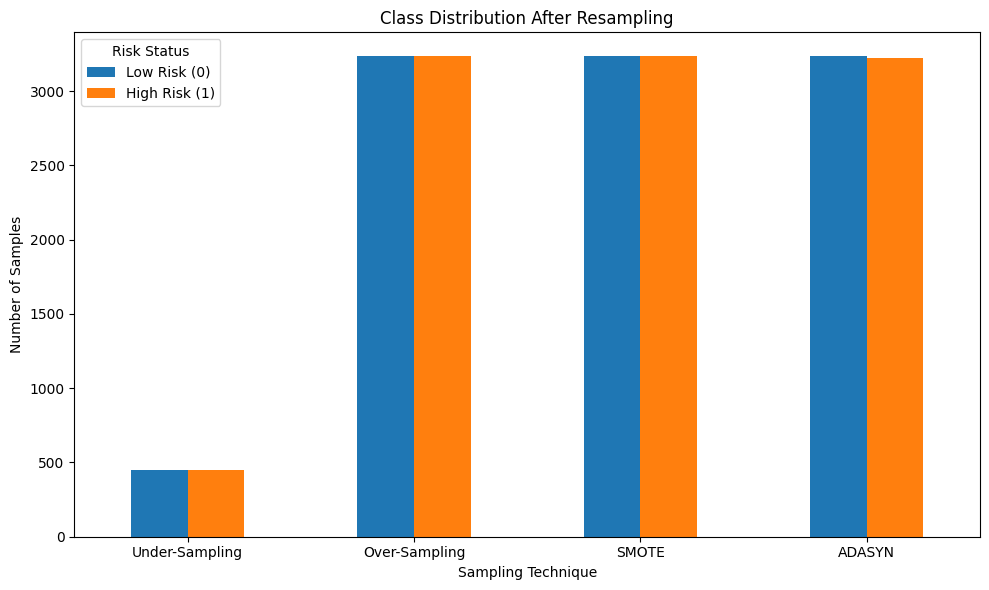


STEP 6 — ORIGINAL DATA MODEL

Original Model Performance:
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0

STEP 7 — TRAIN MODELS USING RESAMPLED DATA

------------------------------------------------------------
Training: Under-Sampling
------------------------------------------------------------
Recall   : 1.0
F1 Score : 0.9911
ROC-AUC  : 1.0

------------------------------------------------------------
Training: Over-Sampling
------------------------------------------------------------
Recall   : 1.0
F1 Score : 0.9911
ROC-AUC  : 1.0

------------------------------------------------------------
Training: SMOTE
------------------------------------------------------------
Recall   : 1.0
F1 Score : 0.9911
ROC-AUC  : 1.0

------------------------------------------------------------
Training: ADASYN
------------------------------------------------------------
Recall   : 1.0
F1 Score : 0.9911
ROC-AUC  : 1.0

STEP 8 — SAMPLING TECHNIQUES PERFORMANCE COMPARISON


,Method,Recall,F1 Score,ROC-AUC,Accuracy,Precision
0,Under-Sampling,1.0,0.9911,1.0,NaN,NaN
1,Over-Sampling,1.0,0.9911,1.0,NaN,NaN
2,SMOTE,1.0,0.9911,1.0,NaN,NaN
3,ADASYN,1.0,0.9911,1.0,NaN,NaN
4,ADASYN,1.0,0.9911,1.0,0.997826,0.982301


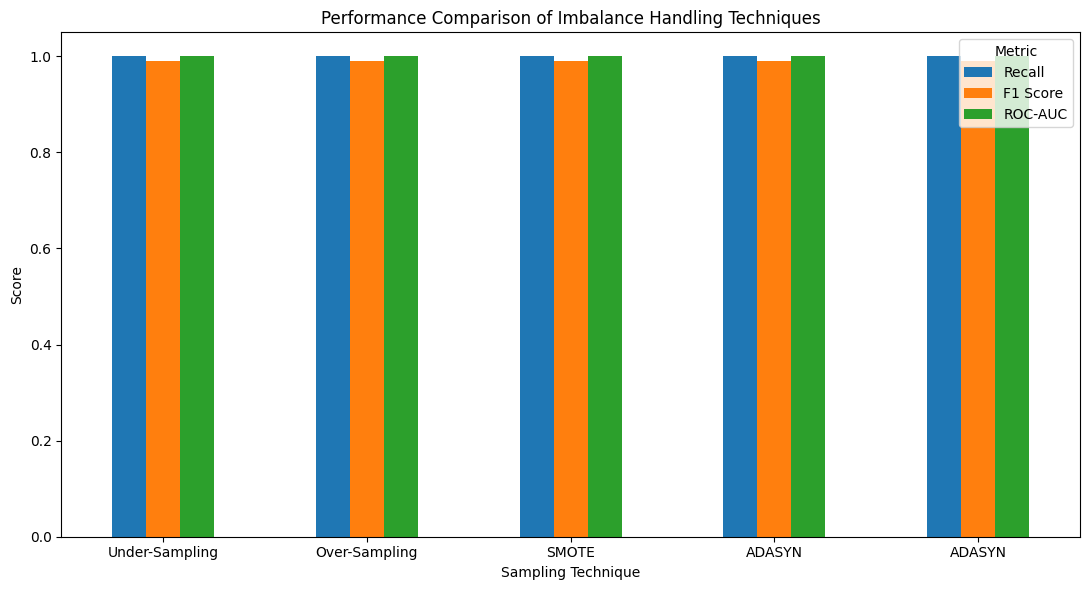


STEP 9 — CONFUSION MATRICES

Original Data:
[[809   0]
 [  0 111]]

Under-Sampling:
[[807   2]
 [  0 111]]

Over-Sampling:
[[807   2]
 [  0 111]]

SMOTE:
[[807   2]
 [  0 111]]

ADASYN:
[[807   2]
 [  0 111]]

STEP 10 — FALSE NEGATIVE COMPARISON


,Method,False Positives,False Negatives
0,Original Data,0,0
1,Under-Sampling,2,0
2,Over-Sampling,2,0
3,SMOTE,2,0
4,ADASYN,2,0



STEP 11 — BEST SAMPLING TECHNIQUE

Best technique based on Recall:
Method : Under-Sampling
Recall : 1.0
F1 Score : 0.9911
ROC-AUC : 1.0

PART D COMPLETED SUCCESSFULLY

Techniques evaluated:
✓ Original Data
✓ Under-Sampling
✓ Over-Sampling
✓ SMOTE
✓ ADASYN

Performance metrics compared:
✓ Recall
✓ F1 Score
✓ ROC-AUC

✓ Class distributions analysed.
✓ Resampling applied only to training data.
✓ Test data kept unchanged.
✓ False Negatives compared.
✓ Best sampling technique identified.

✓ Part D completed.


In [11]:
# ============================================================
# PART D — IMBALANCED DATA HANDLING
# ============================================================

print("=" * 70)
print("PART D — IMBALANCED DATA HANDLING")
print("=" * 70)


# ============================================================
# 1. CHECK ORIGINAL CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("STEP 1 — ORIGINAL TRAINING CLASS DISTRIBUTION")
print("=" * 70)

original_distribution = pd.DataFrame({
    "Count": y_train.value_counts().sort_index(),
    "Percentage (%)": (
        y_train.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

display(original_distribution)

print("\nOriginal Training Distribution:")
print(y_train.value_counts().sort_index())


# ============================================================
# 2. PREPARE DATA FOR RESAMPLING
# ============================================================

print("\n" + "=" * 70)
print("STEP 2 — PREPARE DATA FOR RESAMPLING")
print("=" * 70)

# Convert categorical variables using the same preprocessing
# used for the Logistic Regression model.

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("\nOriginal Training Shape :", X_train.shape)
print("Encoded Training Shape  :", X_train_encoded.shape)
print("Encoded Testing Shape   :", X_test_encoded.shape)

print("\n✓ Categorical features encoded.")
print("✓ Numerical features scaled.")


# ============================================================
# 3. DEFINE RESAMPLING METHODS
# ============================================================

print("\n" + "=" * 70)
print("STEP 3 — DEFINE RESAMPLING METHODS")
print("=" * 70)

sampling_methods = {
    "Under-Sampling": RandomUnderSampler(
        random_state=42
    ),

    "Over-Sampling": RandomOverSampler(
        random_state=42
    ),

    "SMOTE": SMOTE(
        random_state=42
    ),

    "ADASYN": ADASYN(
        random_state=42
    )
}

for method_name in sampling_methods:
    print("✓", method_name)


# ============================================================
# 4. APPLY RESAMPLING
# ============================================================

print("\n" + "=" * 70)
print("STEP 4 — APPLY RESAMPLING TECHNIQUES")
print("=" * 70)

resampled_data = {}

for method_name, sampler in sampling_methods.items():

    print("\n" + "-" * 60)
    print(method_name)
    print("-" * 60)

    X_resampled, y_resampled = sampler.fit_resample(
        X_train_encoded,
        y_train
    )

    resampled_data[method_name] = (
        X_resampled,
        y_resampled
    )

    print("Before Sampling :", X_train_encoded.shape[0])
    print("After Sampling  :", X_resampled.shape[0])

    print("\nClass Distribution:")
    print(
        pd.Series(y_resampled)
        .value_counts()
        .sort_index()
    )


# ============================================================
# 5. VISUALIZE CLASS DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 70)
print("STEP 5 — CLASS DISTRIBUTION AFTER RESAMPLING")
print("=" * 70)

distribution_results = []

for method_name, (X_resampled, y_resampled) in resampled_data.items():

    counts = pd.Series(y_resampled).value_counts().sort_index()

    distribution_results.append({
        "Method": method_name,
        "Low Risk (0)": counts.get(0, 0),
        "High Risk (1)": counts.get(1, 0),
        "Total": len(y_resampled)
    })

distribution_df = pd.DataFrame(
    distribution_results
)

display(distribution_df)


# Plot class distributions

distribution_plot = distribution_df.set_index(
    "Method"
)[
    ["Low Risk (0)", "High Risk (1)"]
]

distribution_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Class Distribution After Resampling")
plt.xlabel("Sampling Technique")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Risk Status")

plt.tight_layout()
plt.show()


# ============================================================
# 6. TRAIN LOGISTIC REGRESSION WITH ORIGINAL DATA
# ============================================================

print("\n" + "=" * 70)
print("STEP 6 — ORIGINAL DATA MODEL")
print("=" * 70)

original_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

original_model.fit(
    X_train_encoded,
    y_train
)

original_pred = original_model.predict(
    X_test_encoded
)

original_probability = original_model.predict_proba(
    X_test_encoded
)[:, 1]


# ============================================================
# 7. EVALUATE ORIGINAL MODEL
# ============================================================

original_recall = recall_score(
    y_test,
    original_pred,
    zero_division=0
)

original_f1 = f1_score(
    y_test,
    original_pred,
    zero_division=0
)

original_auc = roc_auc_score(
    y_test,
    original_probability
)

print("\nOriginal Model Performance:")
print("Recall   :", round(original_recall, 4))
print("F1 Score :", round(original_f1, 4))
print("ROC-AUC  :", round(original_auc, 4))


# ============================================================
# 8. TRAIN MODELS AFTER RESAMPLING
# ============================================================

print("\n" + "=" * 70)
print("STEP 7 — TRAIN MODELS USING RESAMPLED DATA")
print("=" * 70)

sampling_results = []

sampling_models = {}

for method_name, (X_resampled, y_resampled) in resampled_data.items():

    print("\n" + "-" * 60)
    print("Training:", method_name)
    print("-" * 60)

    model = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

    model.fit(
        X_resampled,
        y_resampled
    )

    y_pred_resampled = model.predict(
        X_test_encoded
    )

    y_probability_resampled = model.predict_proba(
        X_test_encoded
    )[:, 1]

    recall = recall_score(
        y_test,
        y_pred_resampled,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_resampled,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_probability_resampled
    )

    sampling_models[method_name] = model

    sampling_results.append({
        "Method": method_name,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))


# ============================================================
# 9. ADD ORIGINAL MODEL TO COMPARISON
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred_resampled
)

precision = precision_score(
    y_test,
    y_pred_resampled,
    zero_division=0
)

sampling_results.append({
    "Method": method_name,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
})

sampling_results_df = pd.DataFrame(
    sampling_results
)

sampling_results_df[
    ["Recall", "F1 Score", "ROC-AUC"]
] = sampling_results_df[
    ["Recall", "F1 Score", "ROC-AUC"]
].round(4)


# ============================================================
# 10. COMPARE ALL TECHNIQUES
# ============================================================

print("\n" + "=" * 70)
print("STEP 8 — SAMPLING TECHNIQUES PERFORMANCE COMPARISON")
print("=" * 70)

display(sampling_results_df)


# ============================================================
# 11. PERFORMANCE VISUALIZATION
# ============================================================

sampling_results_plot = sampling_results_df.set_index(
    "Method"
)[
    ["Recall", "F1 Score", "ROC-AUC"]
]

sampling_results_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Performance Comparison of Imbalance Handling Techniques"
)

plt.xlabel("Sampling Technique")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.legend(
    title="Metric"
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. CONFUSION MATRICES
# ============================================================

print("\n" + "=" * 70)
print("STEP 9 — CONFUSION MATRICES")
print("=" * 70)


# Original model confusion matrix

original_cm = confusion_matrix(
    y_test,
    original_pred
)

print("\nOriginal Data:")
print(original_cm)


# Resampled model confusion matrices

confusion_results = {}

for method_name, model in sampling_models.items():

    predictions = model.predict(
        X_test_encoded
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )

    confusion_results[method_name] = cm

    print("\n" + method_name + ":")
    print(cm)


# ============================================================
# 13. FALSE NEGATIVE COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("STEP 10 — FALSE NEGATIVE COMPARISON")
print("=" * 70)

fn_results = []

# Original model
tn, fp, fn, tp = original_cm.ravel()

fn_results.append({
    "Method": "Original Data",
    "False Positives": fp,
    "False Negatives": fn
})


# Resampled models
for method_name, cm in confusion_results.items():

    tn, fp, fn, tp = cm.ravel()

    fn_results.append({
        "Method": method_name,
        "False Positives": fp,
        "False Negatives": fn
    })


fn_results_df = pd.DataFrame(
    fn_results
)

display(fn_results_df)


# ============================================================
# 14. FIND BEST SAMPLING TECHNIQUE
# ============================================================

print("\n" + "=" * 70)
print("STEP 11 — BEST SAMPLING TECHNIQUE")
print("=" * 70)

# Since identifying High Risk customers is important,
# Recall is given primary importance.

best_sampling_by_recall = sampling_results_df.loc[
    sampling_results_df["Recall"].idxmax()
]

print(
    "\nBest technique based on Recall:"
)

print(
    "Method :",
    best_sampling_by_recall["Method"]
)

print(
    "Recall :",
    best_sampling_by_recall["Recall"]
)

print(
    "F1 Score :",
    best_sampling_by_recall["F1 Score"]
)

print(
    "ROC-AUC :",
    best_sampling_by_recall["ROC-AUC"]
)


# ============================================================
# 15. FINAL PART D SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PART D COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nTechniques evaluated:")
print("✓ Original Data")
print("✓ Under-Sampling")
print("✓ Over-Sampling")
print("✓ SMOTE")
print("✓ ADASYN")

print("\nPerformance metrics compared:")
print("✓ Recall")
print("✓ F1 Score")
print("✓ ROC-AUC")

print("\n✓ Class distributions analysed.")
print("✓ Resampling applied only to training data.")
print("✓ Test data kept unchanged.")
print("✓ False Negatives compared.")
print("✓ Best sampling technique identified.")

print("\n✓ Part D completed.")

PART E — TREE-BASED MODELS

STEP 1 — PREPARE DATA

Training Data Shape : (3680, 27)
Testing Data Shape  : (920, 27)

✓ Original training data will be used.
✓ Test data remains unchanged.
✓ No sampling technique is applied in Part E.

STEP 2 — DECISION TREE

✓ Decision Tree trained successfully.

STEP 3 — DECISION TREE PERFORMANCE

Training Accuracy : 1.0
Testing Accuracy  : 0.9707
Training F1 Score : 1.0

Testing Precision  : 0.9038
Testing Recall     : 0.8468
Testing F1 Score   : 0.8744
Testing ROC-AUC    : 0.9172

STEP 4 — DECISION TREE CLASSIFICATION REPORT
               precision    recall  f1-score   support

 Low Risk (0)       0.98      0.99      0.98       809
High Risk (1)       0.90      0.85      0.87       111

     accuracy                           0.97       920
    macro avg       0.94      0.92      0.93       920
 weighted avg       0.97      0.97      0.97       920


STEP 5 — DECISION TREE CONFUSION MATRIX

Confusion Matrix:
[[799  10]
 [ 17  94]]

True Negative  :

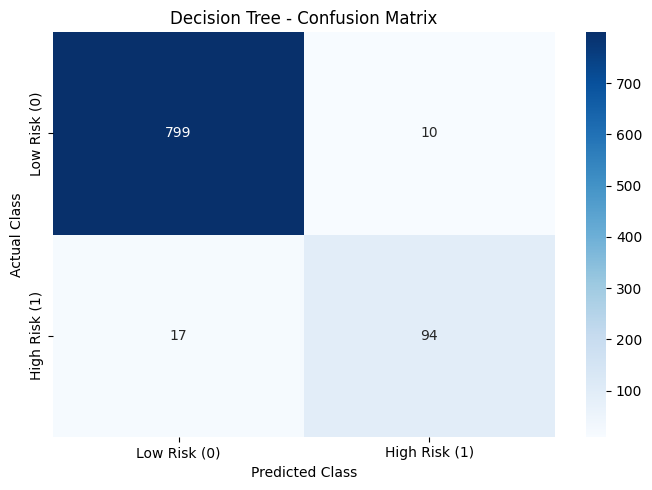


STEP 6 — RANDOM FOREST

✓ Random Forest trained successfully.

STEP 7 — RANDOM FOREST PERFORMANCE

Training Accuracy : 1.0
Testing Accuracy  : 0.9967
Training F1 Score : 1.0

Testing Precision  : 1.0
Testing Recall     : 0.973
Testing F1 Score   : 0.9863
Testing ROC-AUC    : 1.0

STEP 8 — RANDOM FOREST CLASSIFICATION REPORT
               precision    recall  f1-score   support

 Low Risk (0)       1.00      1.00      1.00       809
High Risk (1)       1.00      0.97      0.99       111

     accuracy                           1.00       920
    macro avg       1.00      0.99      0.99       920
 weighted avg       1.00      1.00      1.00       920


STEP 9 — RANDOM FOREST CONFUSION MATRIX

Confusion Matrix:
[[809   0]
 [  3 108]]

True Negative  : 809
False Positive : 0
False Negative : 3
True Positive  : 108

Type-I Error (False Positive) : 0
Type-II Error (False Negative): 3


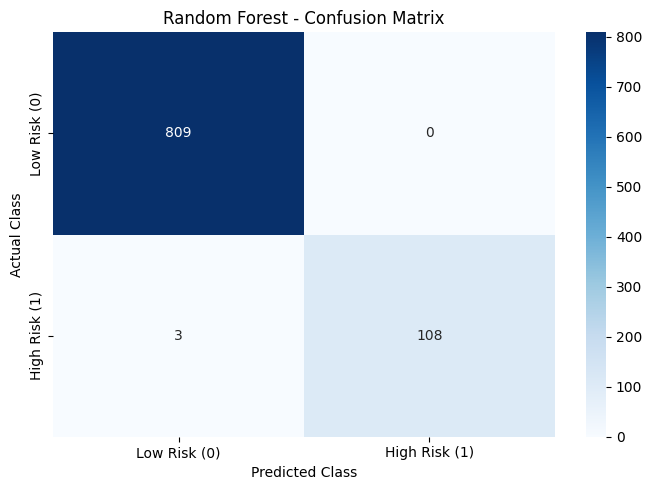


STEP 10 — DECISION TREE VS RANDOM FOREST


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Decision Tree,0.9707,0.9038,0.8468,0.8744,0.9172,10,17
1,Random Forest,0.9967,1.0000,0.9730,0.9863,1.0000,0,3



STEP 11 — OVERFITTING / GENERALIZATION CHECK


,Model,Training Accuracy,Testing Accuracy,Training F1,Testing F1
0,Decision Tree,1.0,0.9707,1.0,0.8744
1,Random Forest,1.0,0.9967,1.0,0.9863



Overfitting Analysis:

A large difference between training and testing performance
may indicate overfitting.

The Decision Tree can easily become deep and fit the training
data very closely. Random Forest combines multiple decision
trees and generally provides better generalization.

The training and testing results above are used to compare
how well both models generalize to unseen data.


STEP 12 — FALSE NEGATIVE COMPARISON
Decision Tree False Negatives : 17
Random Forest False Negatives : 3

Random Forest has fewer False Negatives.
Therefore, Random Forest is better at identifying High Risk customers in this comparison.

STEP 13 — FEATURE IMPORTANCE

Number of encoded features: 27

Top 15 Decision Tree Features:


,Feature,Importance
5,numerical__avg_late_payment_days,0.5521
4,numerical__missed_payments_12m,0.2205
3,numerical__credit_utilization_ratio,0.0723
2,numerical__credit_score,0.0473
8,numerical__cash_advance_count_6m,0.0426
12,numerical__debt_balance_inr,0.0143
10,numerical__failed_login_attempts_3m,0.0124
9,numerical__complaints_last_6m,0.0084
21,categorical__region_West,0.0061
1,numerical__annual_income_inr,0.0061



Top 15 Random Forest Features:


,Feature,Importance
5,numerical__avg_late_payment_days,0.2821
4,numerical__missed_payments_12m,0.1911
2,numerical__credit_score,0.1224
3,numerical__credit_utilization_ratio,0.1081
8,numerical__cash_advance_count_6m,0.0880
10,numerical__failed_login_attempts_3m,0.0498
1,numerical__annual_income_inr,0.0400
9,numerical__complaints_last_6m,0.0292
12,numerical__debt_balance_inr,0.0258
7,numerical__monthly_spend_inr,0.0111


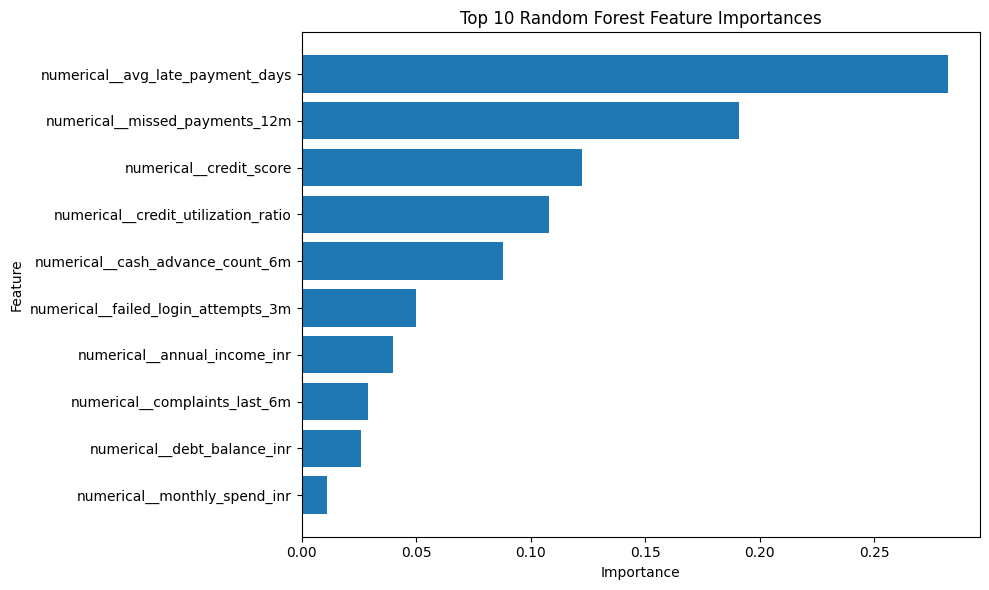


STEP 14 — ROC CURVES


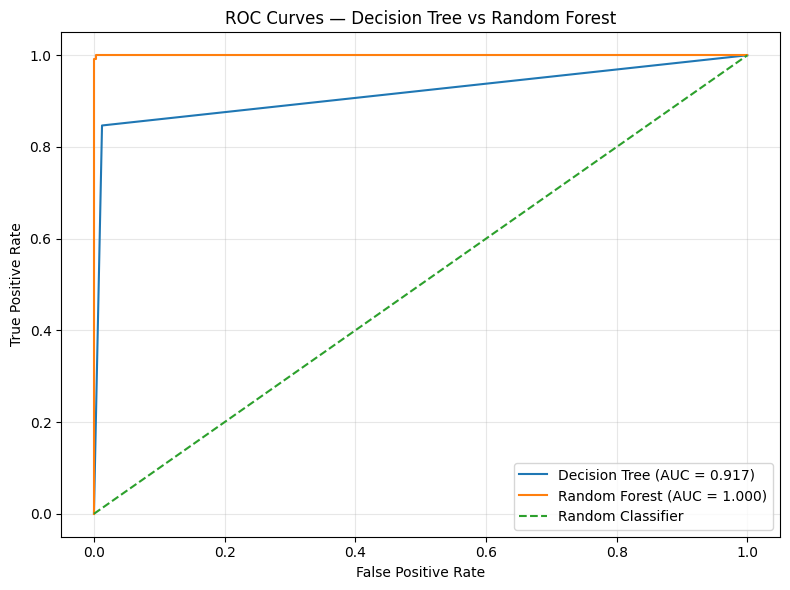


STEP 15 — MODEL COMPARISON SUMMARY

Model preferred based on Recall, F1 Score and business importance:
>>> Random Forest

STEP 16 — BUSINESS INTERPRETATION

Business Interpretation:

The main objective of the risk prediction system is to correctly
identify High Risk customers.

Therefore, Recall is particularly important because a False
Negative means that an actually High Risk customer was predicted
as Low Risk.

False Negatives can be more serious for the bank than False
Positives because failing to identify a High Risk customer may
lead to greater financial risk.

Therefore, when comparing Decision Tree and Random Forest,
Recall and False Negatives are given important consideration,
along with F1 Score and ROC-AUC.


PART E COMPLETED SUCCESSFULLY

✓ Decision Tree implemented
✓ Random Forest implemented

✓ Accuracy calculated
✓ Precision calculated
✓ Recall calculated
✓ F1 Score calculated
✓ ROC-AUC calculated

✓ Classification reports generated
✓ Confusion matrices generated

✓ Tru

In [12]:
# ============================================================
# PART E — TREE-BASED MODELS
# Decision Tree and Random Forest
# ============================================================

print("=" * 70)
print("PART E — TREE-BASED MODELS")
print("=" * 70)


# ============================================================
# STEP 1 — PREPARE DATA
# ============================================================

print("\n" + "=" * 70)
print("STEP 1 — PREPARE DATA")
print("=" * 70)

# X_train_encoded and X_test_encoded were created in Part D.
# They contain the original training and untouched test data.

print("\nTraining Data Shape :", X_train_encoded.shape)
print("Testing Data Shape  :", X_test_encoded.shape)

print("\n✓ Original training data will be used.")
print("✓ Test data remains unchanged.")
print("✓ No sampling technique is applied in Part E.")


# ============================================================
# STEP 2 — DECISION TREE
# ============================================================

print("\n" + "=" * 70)
print("STEP 2 — DECISION TREE")
print("=" * 70)

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(
    X_train_encoded,
    y_train
)

# Training predictions
dt_train_pred = decision_tree.predict(
    X_train_encoded
)

# Testing predictions
dt_test_pred = decision_tree.predict(
    X_test_encoded
)

# Probability for ROC-AUC
dt_test_probability = decision_tree.predict_proba(
    X_test_encoded
)[:, 1]

print("\n✓ Decision Tree trained successfully.")


# ============================================================
# STEP 3 — DECISION TREE PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("STEP 3 — DECISION TREE PERFORMANCE")
print("=" * 70)

dt_train_accuracy = accuracy_score(
    y_train,
    dt_train_pred
)

dt_test_accuracy = accuracy_score(
    y_test,
    dt_test_pred
)

dt_train_f1 = f1_score(
    y_train,
    dt_train_pred,
    zero_division=0
)

dt_test_precision = precision_score(
    y_test,
    dt_test_pred,
    zero_division=0
)

dt_test_recall = recall_score(
    y_test,
    dt_test_pred,
    zero_division=0
)

dt_test_f1 = f1_score(
    y_test,
    dt_test_pred,
    zero_division=0
)

dt_test_auc = roc_auc_score(
    y_test,
    dt_test_probability
)

print("\nTraining Accuracy :", round(dt_train_accuracy, 4))
print("Testing Accuracy  :", round(dt_test_accuracy, 4))
print("Training F1 Score :", round(dt_train_f1, 4))

print("\nTesting Precision  :", round(dt_test_precision, 4))
print("Testing Recall     :", round(dt_test_recall, 4))
print("Testing F1 Score   :", round(dt_test_f1, 4))
print("Testing ROC-AUC    :", round(dt_test_auc, 4))


# ============================================================
# STEP 4 — DECISION TREE CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("STEP 4 — DECISION TREE CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        dt_test_pred,
        target_names=[
            "Low Risk (0)",
            "High Risk (1)"
        ],
        zero_division=0
    )
)


# ============================================================
# STEP 5 — DECISION TREE CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 70)
print("STEP 5 — DECISION TREE CONFUSION MATRIX")
print("=" * 70)

dt_cm = confusion_matrix(
    y_test,
    dt_test_pred
)

dt_tn, dt_fp, dt_fn, dt_tp = dt_cm.ravel()

print("\nConfusion Matrix:")
print(dt_cm)

print("\nTrue Negative  :", dt_tn)
print("False Positive :", dt_fp)
print("False Negative :", dt_fn)
print("True Positive  :", dt_tp)

print("\nType-I Error (False Positive) :", dt_fp)
print("Type-II Error (False Negative):", dt_fn)


# ============================================================
# STEP 6 — DECISION TREE CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low Risk (0)",
        "High Risk (1)"
    ],
    yticklabels=[
        "Low Risk (0)",
        "High Risk (1)"
    ]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()


# ============================================================
# STEP 7 — RANDOM FOREST
# ============================================================

print("\n" + "=" * 70)
print("STEP 6 — RANDOM FOREST")
print("=" * 70)

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train_encoded,
    y_train
)

# Training predictions
rf_train_pred = random_forest.predict(
    X_train_encoded
)

# Testing predictions
rf_test_pred = random_forest.predict(
    X_test_encoded
)

# Probability for ROC-AUC
rf_test_probability = random_forest.predict_proba(
    X_test_encoded
)[:, 1]

print("\n✓ Random Forest trained successfully.")


# ============================================================
# STEP 8 — RANDOM FOREST PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("STEP 7 — RANDOM FOREST PERFORMANCE")
print("=" * 70)

rf_train_accuracy = accuracy_score(
    y_train,
    rf_train_pred
)

rf_test_accuracy = accuracy_score(
    y_test,
    rf_test_pred
)

rf_train_f1 = f1_score(
    y_train,
    rf_train_pred,
    zero_division=0
)

rf_test_precision = precision_score(
    y_test,
    rf_test_pred,
    zero_division=0
)

rf_test_recall = recall_score(
    y_test,
    rf_test_pred,
    zero_division=0
)

rf_test_f1 = f1_score(
    y_test,
    rf_test_pred,
    zero_division=0
)

rf_test_auc = roc_auc_score(
    y_test,
    rf_test_probability
)

print("\nTraining Accuracy :", round(rf_train_accuracy, 4))
print("Testing Accuracy  :", round(rf_test_accuracy, 4))
print("Training F1 Score :", round(rf_train_f1, 4))

print("\nTesting Precision  :", round(rf_test_precision, 4))
print("Testing Recall     :", round(rf_test_recall, 4))
print("Testing F1 Score   :", round(rf_test_f1, 4))
print("Testing ROC-AUC    :", round(rf_test_auc, 4))


# ============================================================
# STEP 9 — RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("STEP 8 — RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        rf_test_pred,
        target_names=[
            "Low Risk (0)",
            "High Risk (1)"
        ],
        zero_division=0
    )
)


# ============================================================
# STEP 10 — RANDOM FOREST CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 70)
print("STEP 9 — RANDOM FOREST CONFUSION MATRIX")
print("=" * 70)

rf_cm = confusion_matrix(
    y_test,
    rf_test_pred
)

rf_tn, rf_fp, rf_fn, rf_tp = rf_cm.ravel()

print("\nConfusion Matrix:")
print(rf_cm)

print("\nTrue Negative  :", rf_tn)
print("False Positive :", rf_fp)
print("False Negative :", rf_fn)
print("True Positive  :", rf_tp)

print("\nType-I Error (False Positive) :", rf_fp)
print("Type-II Error (False Negative):", rf_fn)


# ============================================================
# STEP 11 — RANDOM FOREST CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low Risk (0)",
        "High Risk (1)"
    ],
    yticklabels=[
        "Low Risk (0)",
        "High Risk (1)"
    ]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()


# ============================================================
# STEP 12 — DECISION TREE VS RANDOM FOREST
# ============================================================

print("\n" + "=" * 70)
print("STEP 10 — DECISION TREE VS RANDOM FOREST")
print("=" * 70)

tree_results = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        dt_test_accuracy,
        rf_test_accuracy
    ],

    "Precision": [
        dt_test_precision,
        rf_test_precision
    ],

    "Recall": [
        dt_test_recall,
        rf_test_recall
    ],

    "F1 Score": [
        dt_test_f1,
        rf_test_f1
    ],

    "ROC-AUC": [
        dt_test_auc,
        rf_test_auc
    ],

    "False Positives": [
        dt_fp,
        rf_fp
    ],

    "False Negatives": [
        dt_fn,
        rf_fn
    ]
})

tree_results = tree_results.round(4)

display(tree_results)


# ============================================================
# STEP 13 — OVERFITTING / GENERALIZATION CHECK
# ============================================================

print("\n" + "=" * 70)
print("STEP 11 — OVERFITTING / GENERALIZATION CHECK")
print("=" * 70)

generalization_results = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest"
    ],

    "Training Accuracy": [
        dt_train_accuracy,
        rf_train_accuracy
    ],

    "Testing Accuracy": [
        dt_test_accuracy,
        rf_test_accuracy
    ],

    "Training F1": [
        dt_train_f1,
        rf_train_f1
    ],

    "Testing F1": [
        dt_test_f1,
        rf_test_f1
    ]
})

generalization_results = generalization_results.round(4)

display(generalization_results)


print("""
Overfitting Analysis:

A large difference between training and testing performance
may indicate overfitting.

The Decision Tree can easily become deep and fit the training
data very closely. Random Forest combines multiple decision
trees and generally provides better generalization.

The training and testing results above are used to compare
how well both models generalize to unseen data.
""")


# ============================================================
# STEP 14 — BUSINESS-FOCUSED FALSE NEGATIVE COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("STEP 12 — FALSE NEGATIVE COMPARISON")
print("=" * 70)

print(
    "Decision Tree False Negatives :",
    dt_fn
)

print(
    "Random Forest False Negatives :",
    rf_fn
)

if rf_fn < dt_fn:

    print(
        "\nRandom Forest has fewer False Negatives."
    )

    print(
        "Therefore, Random Forest is better at identifying "
        "High Risk customers in this comparison."
    )

elif dt_fn < rf_fn:

    print(
        "\nDecision Tree has fewer False Negatives."
    )

    print(
        "Therefore, Decision Tree is better at identifying "
        "High Risk customers in this comparison."
    )

else:

    print(
        "\nBoth models have the same number of False Negatives."
    )


# ============================================================
# STEP 15 — FEATURE NAMES
# ============================================================

print("\n" + "=" * 70)
print("STEP 13 — FEATURE IMPORTANCE")
print("=" * 70)

feature_names = preprocessor.get_feature_names_out()

print(
    "\nNumber of encoded features:",
    len(feature_names)
)


# ============================================================
# STEP 16 — DECISION TREE FEATURE IMPORTANCE
# ============================================================

dt_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance":
        decision_tree.feature_importances_

})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Decision Tree Features:")

display(
    dt_importance
    .head(15)
    .round(4)
)


# ============================================================
# STEP 17 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance":
        random_forest.feature_importances_

})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Random Forest Features:")

display(
    rf_importance
    .head(15)
    .round(4)
)


# ============================================================
# STEP 18 — RANDOM FOREST FEATURE IMPORTANCE PLOT
# ============================================================

top_rf_features = (
    rf_importance
    .head(10)
    .sort_values(
        by="Importance"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_rf_features["Feature"],
    top_rf_features["Importance"]
)

plt.title(
    "Top 10 Random Forest Feature Importances"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


# ============================================================
# STEP 19 — ROC CURVES
# ============================================================

print("\n" + "=" * 70)
print("STEP 14 — ROC CURVES")
print("=" * 70)

dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    dt_test_probability
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_test_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC = {dt_test_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_test_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title(
    "ROC Curves — Decision Tree vs Random Forest"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 20 — SELECT BETTER MODEL
# ============================================================

print("\n" + "=" * 70)
print("STEP 15 — MODEL COMPARISON SUMMARY")
print("=" * 70)

# Primary focus: Recall
# Secondary considerations: F1 and ROC-AUC

if (
    rf_test_recall > dt_test_recall
    and rf_test_f1 >= dt_test_f1
):
    better_model = "Random Forest"

elif (
    dt_test_recall > rf_test_recall
    and dt_test_f1 >= rf_test_f1
):
    better_model = "Decision Tree"

else:
    # If the metrics do not clearly favor one model,
    # choose the model with higher Recall.
    if rf_test_recall >= dt_test_recall:
        better_model = "Random Forest"
    else:
        better_model = "Decision Tree"


print(
    "\nModel preferred based on Recall, F1 Score and "
    "business importance:"
)

print(">>>", better_model)


# ============================================================
# STEP 21 — BUSINESS INTERPRETATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 16 — BUSINESS INTERPRETATION")
print("=" * 70)

print("""
Business Interpretation:

The main objective of the risk prediction system is to correctly
identify High Risk customers.

Therefore, Recall is particularly important because a False
Negative means that an actually High Risk customer was predicted
as Low Risk.

False Negatives can be more serious for the bank than False
Positives because failing to identify a High Risk customer may
lead to greater financial risk.

Therefore, when comparing Decision Tree and Random Forest,
Recall and False Negatives are given important consideration,
along with F1 Score and ROC-AUC.
""")


# ============================================================
# STEP 22 — FINAL PART E SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PART E COMPLETED SUCCESSFULLY")
print("=" * 70)

print("""
✓ Decision Tree implemented
✓ Random Forest implemented

✓ Accuracy calculated
✓ Precision calculated
✓ Recall calculated
✓ F1 Score calculated
✓ ROC-AUC calculated

✓ Classification reports generated
✓ Confusion matrices generated

✓ True Positives identified
✓ True Negatives identified
✓ False Positives identified
✓ False Negatives identified

✓ Type-I Errors identified
✓ Type-II Errors identified

✓ Training vs Testing performance compared
✓ Overfitting/generalization checked

✓ Decision Tree feature importance analysed
✓ Random Forest feature importance analysed

✓ ROC curves compared
✓ False Negatives compared
✓ Business impact explained
✓ Better tree-based model identified

✓ Part E completed.
""")

In [13]:
# ============================================================
# PART F — HYPERPARAMETER TUNING
# RandomizedSearchCV + GridSearchCV
# ============================================================

print("=" * 70)
print("PART F — HYPERPARAMETER TUNING")
print("=" * 70)


# ============================================================
# STEP 1 — PREPARE DATA
# ============================================================

print("\n" + "=" * 70)
print("STEP 1 — PREPARE DATA")
print("=" * 70)

print("\nTraining Data Shape :", X_train_encoded.shape)
print("Testing Data Shape  :", X_test_encoded.shape)

print("\n✓ Original training data will be used.")
print("✓ Test data remains untouched.")
print("✓ Hyperparameter tuning will use Stratified Cross-Validation.")


# ============================================================
# STEP 2 — CROSS-VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 2 — STRATIFIED CROSS-VALIDATION")
print("=" * 70)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("\nCross-Validation : 5-Fold Stratified CV")
print("Scoring Metric    : Recall")


# ============================================================
# STEP 3 — DEFINE BASE MODELS
# ============================================================

print("\n" + "=" * 70)
print("STEP 3 — DEFINE MODELS")
print("=" * 70)

dt_base = DecisionTreeClassifier(
    random_state=42
)

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

print("\n✓ Decision Tree defined.")
print("✓ Random Forest defined.")


# ============================================================
# STEP 4 — RANDOMIZED SEARCH PARAMETER DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 70)
print("STEP 4 — RANDOMIZED SEARCH PARAMETERS")
print("=" * 70)

dt_random_params = {
    "max_depth": [3, 5, 7, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 5, 10],
    "criterion": ["gini", "entropy"]
}

rf_random_params = {
    "n_estimators": [100, 150, 200, 250, 300],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "criterion": ["gini", "entropy"]
}

print("\nDecision Tree parameters:")
for parameter in dt_random_params:
    print("✓", parameter)

print("\nRandom Forest parameters:")
for parameter in rf_random_params:
    print("✓", parameter)


# ============================================================
# STEP 5 — RANDOMIZED SEARCH: DECISION TREE
# ============================================================

print("\n" + "=" * 70)
print("STEP 5 — RANDOMIZED SEARCH: DECISION TREE")
print("=" * 70)

dt_random_search = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=dt_random_params,
    n_iter=30,
    scoring="recall",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

dt_random_search.fit(
    X_train_encoded,
    y_train
)

print("\n✓ Decision Tree RandomizedSearchCV completed.")

print("\nBest Parameters:")
print(dt_random_search.best_params_)

print(
    "\nBest Cross-Validation Recall :",
    round(dt_random_search.best_score_, 4)
)


# ============================================================
# STEP 6 — RANDOMIZED SEARCH: RANDOM FOREST
# ============================================================

print("\n" + "=" * 70)
print("STEP 6 — RANDOMIZED SEARCH: RANDOM FOREST")
print("=" * 70)

rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_random_params,
    n_iter=30,
    scoring="recall",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

rf_random_search.fit(
    X_train_encoded,
    y_train
)

print("\n✓ Random Forest RandomizedSearchCV completed.")

print("\nBest Parameters:")
print(rf_random_search.best_params_)

print(
    "\nBest Cross-Validation Recall :",
    round(rf_random_search.best_score_, 4)
)


# ============================================================
# STEP 7 — GRID SEARCH PARAMETERS
# ============================================================

print("\n" + "=" * 70)
print("STEP 7 — GRID SEARCH PARAMETERS")
print("=" * 70)

# Use the best RandomizedSearchCV parameters as a starting point
# and test nearby values more systematically.

best_dt_params = dt_random_search.best_params_

best_rf_params = rf_random_search.best_params_


# Decision Tree Grid

dt_grid_params = {
    "max_depth": sorted(
        list(
            set(
                [
                    best_dt_params["max_depth"],
                    5,
                    7,
                    10,
                    15
                ]
            )
        ),
        key=lambda x: (x is None, x if x is not None else 999)
    ),

    "min_samples_split": sorted(
        list(
            set(
                [
                    best_dt_params["min_samples_split"],
                    2,
                    5,
                    10
                ]
            )
        )
    ),

    "min_samples_leaf": sorted(
        list(
            set(
                [
                    best_dt_params["min_samples_leaf"],
                    1,
                    2,
                    4,
                    5
                ]
            )
        )
    ),

    "criterion": [
        best_dt_params["criterion"]
    ]
}


# Random Forest Grid

rf_grid_params = {
    "n_estimators": sorted(
        list(
            set(
                [
                    best_rf_params["n_estimators"],
                    100,
                    150,
                    200,
                    250
                ]
            )
        )
    ),

    "max_depth": list(
        dict.fromkeys(
            [
                best_rf_params["max_depth"],
                5,
                10,
                15,
                20
            ]
        )
    ),

    "min_samples_split": sorted(
        list(
            set(
                [
                    best_rf_params["min_samples_split"],
                    2,
                    5,
                    10
                ]
            )
        )
    ),

    "min_samples_leaf": sorted(
        list(
            set(
                [
                    best_rf_params["min_samples_leaf"],
                    1,
                    2,
                    4
                ]
            )
        )
    ),

    "max_features": [
        best_rf_params["max_features"]
    ],

    "criterion": [
        best_rf_params["criterion"]
    ]
}

print("\n✓ Focused GridSearch parameters created.")
print("✓ GridSearch will refine the RandomizedSearch results.")


# ============================================================
# STEP 8 — GRID SEARCH: DECISION TREE
# ============================================================

print("\n" + "=" * 70)
print("STEP 8 — GRID SEARCH: DECISION TREE")
print("=" * 70)

dt_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=dt_grid_params,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

dt_grid_search.fit(
    X_train_encoded,
    y_train
)

print("\n✓ Decision Tree GridSearchCV completed.")

print("\nBest Parameters:")
print(dt_grid_search.best_params_)

print(
    "\nBest Cross-Validation Recall :",
    round(dt_grid_search.best_score_, 4)
)


# ============================================================
# STEP 9 — GRID SEARCH: RANDOM FOREST
# ============================================================

print("\n" + "=" * 70)
print("STEP 9 — GRID SEARCH: RANDOM FOREST")
print("=" * 70)

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_grid_params,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

rf_grid_search.fit(
    X_train_encoded,
    y_train
)

print("\n✓ Random Forest GridSearchCV completed.")

print("\nBest Parameters:")
print(rf_grid_search.best_params_)

print(
    "\nBest Cross-Validation Recall :",
    round(rf_grid_search.best_score_, 4)
)


# ============================================================
# STEP 10 — SELECT FINAL TUNED MODELS
# ============================================================

print("\n" + "=" * 70)
print("STEP 10 — FINAL TUNED MODELS")
print("=" * 70)

tuned_dt = dt_grid_search.best_estimator_

tuned_rf = rf_grid_search.best_estimator_

print("\n✓ Tuned Decision Tree selected.")
print("✓ Tuned Random Forest selected.")


# ============================================================
# STEP 11 — PREDICT WITH TUNED DECISION TREE
# ============================================================

print("\n" + "=" * 70)
print("STEP 11 — TUNED DECISION TREE EVALUATION")
print("=" * 70)

tuned_dt_pred = tuned_dt.predict(
    X_test_encoded
)

tuned_dt_probability = tuned_dt.predict_proba(
    X_test_encoded
)[:, 1]

tuned_dt_accuracy = accuracy_score(
    y_test,
    tuned_dt_pred
)

tuned_dt_precision = precision_score(
    y_test,
    tuned_dt_pred,
    zero_division=0
)

tuned_dt_recall = recall_score(
    y_test,
    tuned_dt_pred,
    zero_division=0
)

tuned_dt_f1 = f1_score(
    y_test,
    tuned_dt_pred,
    zero_division=0
)

tuned_dt_auc = roc_auc_score(
    y_test,
    tuned_dt_probability
)

tuned_dt_cm = confusion_matrix(
    y_test,
    tuned_dt_pred
)

tuned_dt_tn, tuned_dt_fp, tuned_dt_fn, tuned_dt_tp = (
    tuned_dt_cm.ravel()
)

print("\nAccuracy  :", round(tuned_dt_accuracy, 4))
print("Precision :", round(tuned_dt_precision, 4))
print("Recall    :", round(tuned_dt_recall, 4))
print("F1 Score  :", round(tuned_dt_f1, 4))
print("ROC-AUC   :", round(tuned_dt_auc, 4))

print("\nFalse Positives :", tuned_dt_fp)
print("False Negatives :", tuned_dt_fn)


# ============================================================
# STEP 12 — PREDICT WITH TUNED RANDOM FOREST
# ============================================================

print("\n" + "=" * 70)
print("STEP 12 — TUNED RANDOM FOREST EVALUATION")
print("=" * 70)

tuned_rf_pred = tuned_rf.predict(
    X_test_encoded
)

tuned_rf_probability = tuned_rf.predict_proba(
    X_test_encoded
)[:, 1]

tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_pred
)

tuned_rf_precision = precision_score(
    y_test,
    tuned_rf_pred,
    zero_division=0
)

tuned_rf_recall = recall_score(
    y_test,
    tuned_rf_pred,
    zero_division=0
)

tuned_rf_f1 = f1_score(
    y_test,
    tuned_rf_pred,
    zero_division=0
)

tuned_rf_auc = roc_auc_score(
    y_test,
    tuned_rf_probability
)

tuned_rf_cm = confusion_matrix(
    y_test,
    tuned_rf_pred
)

tuned_rf_tn, tuned_rf_fp, tuned_rf_fn, tuned_rf_tp = (
    tuned_rf_cm.ravel()
)

print("\nAccuracy  :", round(tuned_rf_accuracy, 4))
print("Precision :", round(tuned_rf_precision, 4))
print("Recall    :", round(tuned_rf_recall, 4))
print("F1 Score  :", round(tuned_rf_f1, 4))
print("ROC-AUC   :", round(tuned_rf_auc, 4))

print("\nFalse Positives :", tuned_rf_fp)
print("False Negatives :", tuned_rf_fn)


# ============================================================
# STEP 13 — UNTUNED VS TUNED DECISION TREE
# ============================================================

print("\n" + "=" * 70)
print("STEP 13 — DECISION TREE: UNTUNED VS TUNED")
print("=" * 70)

dt_tuning_comparison = pd.DataFrame({

    "Model": [
        "Decision Tree - Untuned",
        "Decision Tree - Tuned"
    ],

    "Accuracy": [
        dt_test_accuracy,
        tuned_dt_accuracy
    ],

    "Precision": [
        dt_test_precision,
        tuned_dt_precision
    ],

    "Recall": [
        dt_test_recall,
        tuned_dt_recall
    ],

    "F1 Score": [
        dt_test_f1,
        tuned_dt_f1
    ],

    "ROC-AUC": [
        dt_test_auc,
        tuned_dt_auc
    ],

    "False Positives": [
        dt_fp,
        tuned_dt_fp
    ],

    "False Negatives": [
        dt_fn,
        tuned_dt_fn
    ]
})

dt_tuning_comparison = dt_tuning_comparison.round(4)

display(dt_tuning_comparison)


# ============================================================
# STEP 14 — UNTUNED VS TUNED RANDOM FOREST
# ============================================================

print("\n" + "=" * 70)
print("STEP 14 — RANDOM FOREST: UNTUNED VS TUNED")
print("=" * 70)

rf_tuning_comparison = pd.DataFrame({

    "Model": [
        "Random Forest - Untuned",
        "Random Forest - Tuned"
    ],

    "Accuracy": [
        rf_test_accuracy,
        tuned_rf_accuracy
    ],

    "Precision": [
        rf_test_precision,
        tuned_rf_precision
    ],

    "Recall": [
        rf_test_recall,
        tuned_rf_recall
    ],

    "F1 Score": [
        rf_test_f1,
        tuned_rf_f1
    ],

    "ROC-AUC": [
        rf_test_auc,
        tuned_rf_auc
    ],

    "False Positives": [
        rf_fp,
        tuned_rf_fp
    ],

    "False Negatives": [
        rf_fn,
        tuned_rf_fn
    ]
})

rf_tuning_comparison = rf_tuning_comparison.round(4)

display(rf_tuning_comparison)


# ============================================================
# STEP 15 — COMPLETE TUNING COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("STEP 15 — COMPLETE HYPERPARAMETER TUNING COMPARISON")
print("=" * 70)

tuning_results = pd.DataFrame({

    "Model": [
        "Decision Tree - Untuned",
        "Decision Tree - Tuned",
        "Random Forest - Untuned",
        "Random Forest - Tuned"
    ],

    "Accuracy": [
        dt_test_accuracy,
        tuned_dt_accuracy,
        rf_test_accuracy,
        tuned_rf_accuracy
    ],

    "Precision": [
        dt_test_precision,
        tuned_dt_precision,
        rf_test_precision,
        tuned_rf_precision
    ],

    "Recall": [
        dt_test_recall,
        tuned_dt_recall,
        rf_test_recall,
        tuned_rf_recall
    ],

    "F1 Score": [
        dt_test_f1,
        tuned_dt_f1,
        rf_test_f1,
        tuned_rf_f1
    ],

    "ROC-AUC": [
        dt_test_auc,
        tuned_dt_auc,
        rf_test_auc,
        tuned_rf_auc
    ],

    "False Positives": [
        dt_fp,
        tuned_dt_fp,
        rf_fp,
        tuned_rf_fp
    ],

    "False Negatives": [
        dt_fn,
        tuned_dt_fn,
        rf_fn,
        tuned_rf_fn
    ]
})

tuning_results = tuning_results.round(4)

display(tuning_results)


# ============================================================
# STEP 16 — BEST TUNED MODEL
# ============================================================

print("\n" + "=" * 70)
print("STEP 16 — BEST TUNED MODEL")
print("=" * 70)

candidate_results = pd.DataFrame({

    "Model": [
        "Tuned Decision Tree",
        "Tuned Random Forest"
    ],

    "Recall": [
        tuned_dt_recall,
        tuned_rf_recall
    ],

    "F1 Score": [
        tuned_dt_f1,
        tuned_rf_f1
    ],

    "ROC-AUC": [
        tuned_dt_auc,
        tuned_rf_auc
    ],

    "False Negatives": [
        tuned_dt_fn,
        tuned_rf_fn
    ]
})

display(
    candidate_results.round(4)
)


# Primary priority = Recall
# Secondary = F1 Score and ROC-AUC
# Business concern = minimize False Negatives

best_tuned_index = candidate_results[
    "Recall"
].idxmax()

best_tuned_model_name = candidate_results.loc[
    best_tuned_index,
    "Model"
]

print(
    "\nBest tuned model based primarily on Recall:"
)

print(
    ">>>",
    best_tuned_model_name
)


# ============================================================
# STEP 17 — BEST PARAMETERS SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STEP 17 — BEST HYPERPARAMETERS")
print("=" * 70)

print("\nBest Decision Tree Parameters:")
print(dt_grid_search.best_params_)

print("\nBest Random Forest Parameters:")
print(rf_grid_search.best_params_)


# ============================================================
# STEP 18 — BUSINESS INTERPRETATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 18 — BUSINESS INTERPRETATION")
print("=" * 70)

print("""
Hyperparameter tuning searches for model settings that improve
performance on unseen data.

RandomizedSearchCV explores a larger parameter space by testing
a selected number of random parameter combinations.

GridSearchCV then performs a more systematic search over a
focused set of parameter values.

For this banking risk prediction problem, Recall is important
because the main concern is identifying High Risk customers.

A False Negative means that a genuinely High Risk customer was
predicted as Low Risk. Therefore, False Negatives should be
carefully considered along with Recall, F1-Score and ROC-AUC.

The tuned models are compared with the untuned models to
determine whether hyperparameter tuning improved generalization.
""")


# ============================================================
# STEP 19 — FINAL PART F SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PART F COMPLETED SUCCESSFULLY")
print("=" * 70)

print("""
✓ Stratified 5-fold cross-validation used
✓ Decision Tree RandomizedSearchCV completed
✓ Random Forest RandomizedSearchCV completed

✓ Decision Tree GridSearchCV completed
✓ Random Forest GridSearchCV completed

✓ Best hyperparameters identified
✓ Tuned Decision Tree evaluated
✓ Tuned Random Forest evaluated

✓ Untuned vs Tuned Decision Tree compared
✓ Untuned vs Tuned Random Forest compared

✓ Accuracy compared
✓ Precision compared
✓ Recall compared
✓ F1 Score compared
✓ ROC-AUC compared

✓ False Positives compared
✓ False Negatives compared

✓ Business impact explained
✓ Best tuned model identified

✓ Part F completed.
""")


PART F — HYPERPARAMETER TUNING

STEP 1 — PREPARE DATA

Training Data Shape : (3680, 27)
Testing Data Shape  : (920, 27)

✓ Original training data will be used.
✓ Test data remains untouched.
✓ Hyperparameter tuning will use Stratified Cross-Validation.

STEP 2 — STRATIFIED CROSS-VALIDATION

Cross-Validation : 5-Fold Stratified CV
Scoring Metric    : Recall

STEP 3 — DEFINE MODELS

✓ Decision Tree defined.
✓ Random Forest defined.

STEP 4 — RANDOMIZED SEARCH PARAMETERS

Decision Tree parameters:
✓ max_depth
✓ min_samples_split
✓ min_samples_leaf
✓ criterion

Random Forest parameters:
✓ n_estimators
✓ max_depth
✓ min_samples_split
✓ min_samples_leaf
✓ max_features
✓ criterion

STEP 5 — RANDOMIZED SEARCH: DECISION TREE

✓ Decision Tree RandomizedSearchCV completed.

Best Parameters:
{'min_samples_split': 15, 'min_samples_leaf': 2, 'max_depth': 7, 'criterion': 'entropy'}

Best Cross-Validation Recall : 0.897

STEP 6 — RANDOMIZED SEARCH: RANDOM FOREST

✓ Random Forest RandomizedSearchCV com

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Decision Tree - Untuned,0.9707,0.9038,0.8468,0.8744,0.9172,10,17
1,Decision Tree - Tuned,0.9804,0.8974,0.9459,0.9211,0.9855,12,6



STEP 14 — RANDOM FOREST: UNTUNED VS TUNED


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Random Forest - Untuned,0.9967,1.0,0.973,0.9863,1.0,0,3
1,Random Forest - Tuned,0.9989,1.0,0.991,0.9955,1.0,0,1



STEP 15 — COMPLETE HYPERPARAMETER TUNING COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Decision Tree - Untuned,0.9707,0.9038,0.8468,0.8744,0.9172,10,17
1,Decision Tree - Tuned,0.9804,0.8974,0.9459,0.9211,0.9855,12,6
2,Random Forest - Untuned,0.9967,1.0000,0.9730,0.9863,1.0000,0,3
3,Random Forest - Tuned,0.9989,1.0000,0.9910,0.9955,1.0000,0,1



STEP 16 — BEST TUNED MODEL


,Model,Recall,F1 Score,ROC-AUC,False Negatives
0,Tuned Decision Tree,0.9459,0.9211,0.9855,6
1,Tuned Random Forest,0.9910,0.9955,1.0000,1



Best tuned model based primarily on Recall:
>>> Tuned Random Forest

STEP 17 — BEST HYPERPARAMETERS

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 15}

Best Random Forest Parameters:
{'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}

STEP 18 — BUSINESS INTERPRETATION

Hyperparameter tuning searches for model settings that improve
performance on unseen data.

RandomizedSearchCV explores a larger parameter space by testing
a selected number of random parameter combinations.

GridSearchCV then performs a more systematic search over a
focused set of parameter values.

For this banking risk prediction problem, Recall is important
because the main concern is identifying High Risk customers.

A False Negative means that a genuinely High Risk customer was
predicted as Low Risk. Therefore, False Negatives should be
carefully considered along 

PART G — FINAL MODEL EVALUATION & MODEL SELECTION

STEP 1 — FINAL MODEL PREDICTIONS

✓ Decision Tree predictions generated.
✓ Tuned Decision Tree predictions generated.
✓ Random Forest predictions generated.
✓ Tuned Random Forest predictions generated.

STEP 2 — FINAL MODEL METRICS


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Decision Tree - Untuned,0.9707,0.9038,0.8468,0.8744,0.9172,10,17
1,Decision Tree - Tuned,0.9804,0.8974,0.9459,0.9211,0.9855,12,6
2,Random Forest - Untuned,0.9967,1.0000,0.9730,0.9863,1.0000,0,3
3,Random Forest - Tuned,0.9989,1.0000,0.9910,0.9955,1.0000,0,1



STEP 3 — ROC CURVE COMPARISON


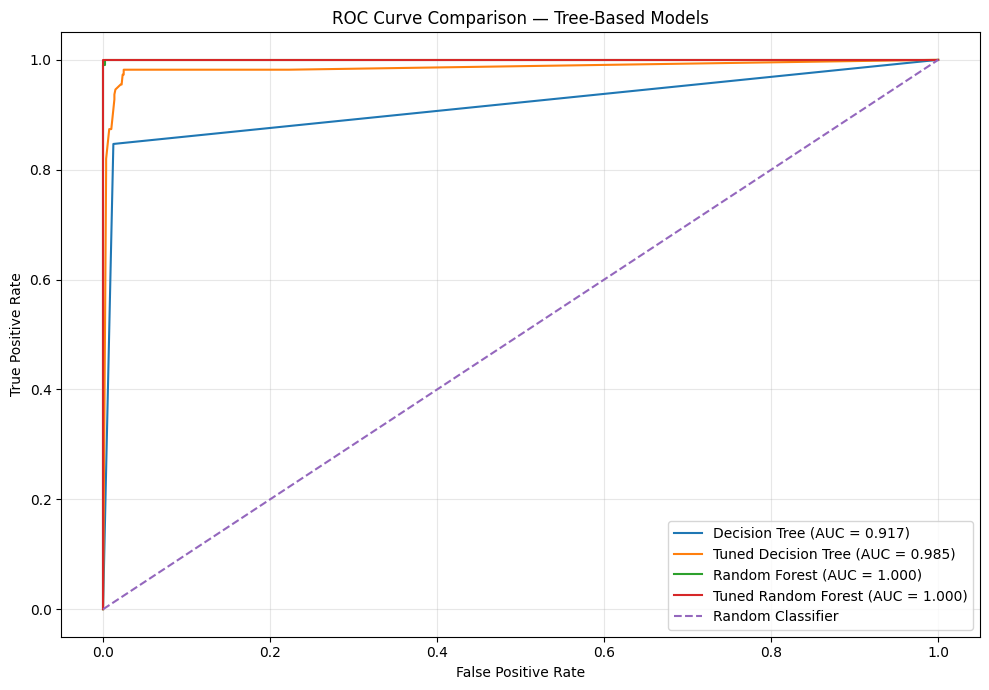


STEP 4 — ROC-AUC COMPARISON


,Model,ROC-AUC
3,Random Forest - Tuned,1.0000
2,Random Forest - Untuned,1.0000
1,Decision Tree - Tuned,0.9855
0,Decision Tree - Untuned,0.9172


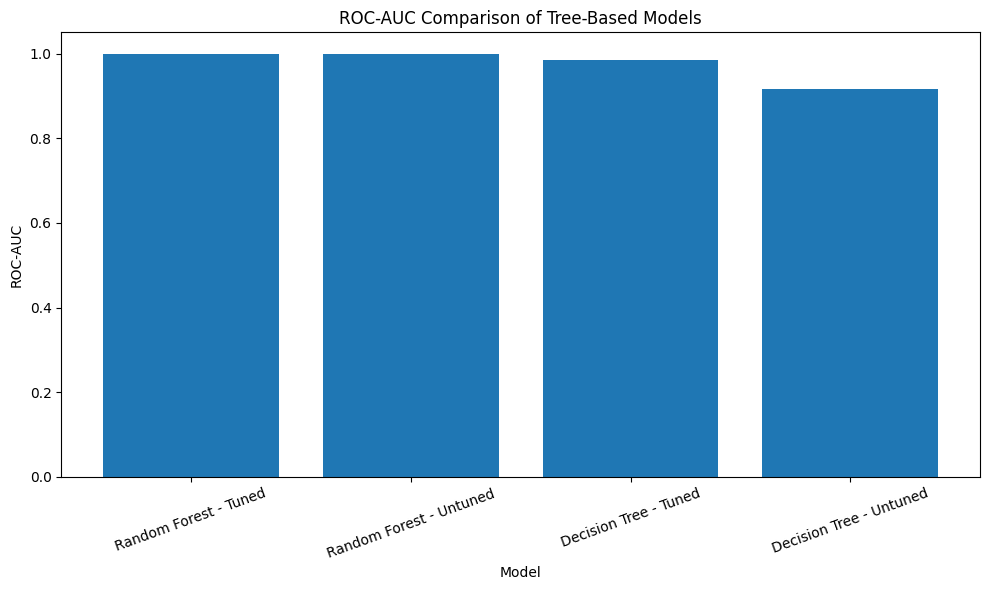


STEP 5 — CONFUSION MATRIX COMPARISON


,Model,True Negatives,False Positives,False Negatives,True Positives
0,Decision Tree - Untuned,799,10,17,94
1,Decision Tree - Tuned,797,12,6,105
2,Random Forest - Untuned,809,0,3,108
3,Random Forest - Tuned,809,0,1,110



STEP 6 — FALSE NEGATIVE COMPARISON


,Model,Recall,F1 Score,ROC-AUC,False Negatives
3,Random Forest - Tuned,0.9910,0.9955,1.0000,1
2,Random Forest - Untuned,0.9730,0.9863,1.0000,3
1,Decision Tree - Tuned,0.9459,0.9211,0.9855,6
0,Decision Tree - Untuned,0.8468,0.8744,0.9172,17



STEP 7 — BUSINESS-FOCUSED EVALUATION

For this banking risk prediction problem, identifying High Risk
customers correctly is very important.

Therefore:

1. Higher Recall is preferred.
2. Lower False Negatives are preferred.
3. Higher F1 Score is preferred.
4. Higher ROC-AUC is preferred.

A False Negative means that an actual High Risk customer was
incorrectly classified as Low Risk.

Therefore, reducing False Negatives is an important business
objective.


STEP 8 — FINAL MODEL SELECTION


,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,1,Tuned Random Forest,0.9989,1.0000,0.9910,0.9955,1.0000,0,1
1,2,Tuned Decision Tree,0.9804,0.8974,0.9459,0.9211,0.9855,12,6



STEP 9 — SELECTED FINAL MODEL

FINAL SELECTED MODEL:
>>> Tuned Random Forest

Final Performance:
Accuracy         : 0.9989
Precision        : 1.0
Recall           : 0.991
F1 Score         : 0.9955
ROC-AUC          : 1.0
False Positives  : 0
False Negatives  : 1

STEP 10 — FINAL BUSINESS JUSTIFICATION

The final selected model is Tuned Random Forest.

The model was selected by giving high importance to Recall
because the main objective is to correctly identify High Risk
customers.

A False Negative means that an actual High Risk customer was
predicted as Low Risk. Therefore, minimizing False Negatives
is important for reducing financial risk.

The selected model achieved:

Accuracy        : 0.9989
Precision       : 1.0000
Recall          : 0.9910
F1 Score        : 0.9955
ROC-AUC         : 1.0000
False Positives : 0
False Negatives : 1


STEP 11 — FINAL CONCLUSION

FINAL CONCLUSION:

The tuned Decision Tree and tuned Random Forest were evaluated
using the same untouched test data.

The 

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Decision Tree - Untuned,0.9707,0.9038,0.8468,0.8744,0.9172,10,17
1,Decision Tree - Tuned,0.9804,0.8974,0.9459,0.9211,0.9855,12,6
2,Random Forest - Untuned,0.9967,1.0000,0.9730,0.9863,1.0000,0,3
3,Random Forest - Tuned,0.9989,1.0000,0.9910,0.9955,1.0000,0,1



PART G COMPLETED SUCCESSFULLY

✓ Final models evaluated
✓ Untuned vs Tuned comparison completed
✓ Accuracy compared
✓ Precision compared
✓ Recall compared
✓ F1 Score compared
✓ ROC-AUC compared

✓ ROC curves generated
✓ AUC comparison generated
✓ Confusion matrices compared
✓ False Positives compared
✓ False Negatives compared

✓ Business-focused evaluation completed
✓ Final tuned model selected
✓ Business justification provided
✓ Final conclusion provided

✓ Part G completed successfully.



In [18]:
# ============================================================
# PART G — FINAL MODEL EVALUATION & MODEL SELECTION
# ============================================================

print("=" * 70)
print("PART G — FINAL MODEL EVALUATION & MODEL SELECTION")
print("=" * 70)


# ============================================================
# STEP 1 — FINAL PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("STEP 1 — FINAL MODEL PREDICTIONS")
print("=" * 70)


# Decision Tree - Untuned
dt_final_pred = decision_tree.predict(
    X_test_encoded
)

dt_final_probability = decision_tree.predict_proba(
    X_test_encoded
)[:, 1]


# Decision Tree - Tuned
tuned_dt_final_pred = tuned_dt.predict(
    X_test_encoded
)

tuned_dt_final_probability = tuned_dt.predict_proba(
    X_test_encoded
)[:, 1]


# Random Forest - Untuned
rf_final_pred = random_forest.predict(
    X_test_encoded
)

rf_final_probability = random_forest.predict_proba(
    X_test_encoded
)[:, 1]


# Random Forest - Tuned
tuned_rf_final_pred = tuned_rf.predict(
    X_test_encoded
)

tuned_rf_final_probability = tuned_rf.predict_proba(
    X_test_encoded
)[:, 1]


print("\n✓ Decision Tree predictions generated.")
print("✓ Tuned Decision Tree predictions generated.")
print("✓ Random Forest predictions generated.")
print("✓ Tuned Random Forest predictions generated.")


# ============================================================
# STEP 2 — FINAL MODEL METRICS
# ============================================================

print("\n" + "=" * 70)
print("STEP 2 — FINAL MODEL METRICS")
print("=" * 70)


def calculate_final_metrics(
    model_name,
    y_true,
    y_pred,
    probability
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        probability
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "False Positives": fp,
        "False Negatives": fn
    }


# Calculate results

dt_result = calculate_final_metrics(
    "Decision Tree - Untuned",
    y_test,
    dt_final_pred,
    dt_final_probability
)


tuned_dt_result = calculate_final_metrics(
    "Decision Tree - Tuned",
    y_test,
    tuned_dt_final_pred,
    tuned_dt_final_probability
)


rf_result = calculate_final_metrics(
    "Random Forest - Untuned",
    y_test,
    rf_final_pred,
    rf_final_probability
)


tuned_rf_result = calculate_final_metrics(
    "Random Forest - Tuned",
    y_test,
    tuned_rf_final_pred,
    tuned_rf_final_probability
)


final_results = pd.DataFrame([
    dt_result,
    tuned_dt_result,
    rf_result,
    tuned_rf_result
])


final_results[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
] = final_results[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].round(4)


display(final_results)


# ============================================================
# STEP 3 — ROC CURVE COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("STEP 3 — ROC CURVE COMPARISON")
print("=" * 70)


# Decision Tree
dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    dt_final_probability
)


# Tuned Decision Tree
tuned_dt_fpr, tuned_dt_tpr, _ = roc_curve(
    y_test,
    tuned_dt_final_probability
)


# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_final_probability
)


# Tuned Random Forest
tuned_rf_fpr, tuned_rf_tpr, _ = roc_curve(
    y_test,
    tuned_rf_final_probability
)


plt.figure(figsize=(10, 7))


plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC = {dt_result['ROC-AUC']:.3f})"
)


plt.plot(
    tuned_dt_fpr,
    tuned_dt_tpr,
    label=f"Tuned Decision Tree (AUC = {tuned_dt_result['ROC-AUC']:.3f})"
)


plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_result['ROC-AUC']:.3f})"
)


plt.plot(
    tuned_rf_fpr,
    tuned_rf_tpr,
    label=f"Tuned Random Forest (AUC = {tuned_rf_result['ROC-AUC']:.3f})"
)


# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)


plt.title(
    "ROC Curve Comparison — Tree-Based Models"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# STEP 4 — ROC-AUC COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("STEP 4 — ROC-AUC COMPARISON")
print("=" * 70)


auc_comparison = final_results[
    [
        "Model",
        "ROC-AUC"
    ]
].sort_values(
    by="ROC-AUC",
    ascending=False
)


display(auc_comparison)


plt.figure(figsize=(10, 6))


plt.bar(
    auc_comparison["Model"],
    auc_comparison["ROC-AUC"]
)


plt.title(
    "ROC-AUC Comparison of Tree-Based Models"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "ROC-AUC"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


# ============================================================
# STEP 5 — CONFUSION MATRIX COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("STEP 5 — CONFUSION MATRIX COMPARISON")
print("=" * 70)


model_predictions = {

    "Decision Tree - Untuned":
        dt_final_pred,

    "Decision Tree - Tuned":
        tuned_dt_final_pred,

    "Random Forest - Untuned":
        rf_final_pred,

    "Random Forest - Tuned":
        tuned_rf_final_pred
}


confusion_results = []


for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions
    )

    tn, fp, fn, tp = cm.ravel()

    confusion_results.append({

        "Model": model_name,

        "True Negatives": tn,

        "False Positives": fp,

        "False Negatives": fn,

        "True Positives": tp
    })


confusion_df = pd.DataFrame(
    confusion_results
)


display(confusion_df)


# ============================================================
# STEP 6 — FALSE NEGATIVE COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("STEP 6 — FALSE NEGATIVE COMPARISON")
print("=" * 70)


fn_comparison = final_results[
    [
        "Model",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "False Negatives"
    ]
].sort_values(
    by=[
        "Recall",
        "False Negatives"
    ],
    ascending=[
        False,
        True
    ]
)


display(fn_comparison)


# ============================================================
# STEP 7 — BUSINESS-FOCUSED EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 7 — BUSINESS-FOCUSED EVALUATION")
print("=" * 70)


print("""
For this banking risk prediction problem, identifying High Risk
customers correctly is very important.

Therefore:

1. Higher Recall is preferred.
2. Lower False Negatives are preferred.
3. Higher F1 Score is preferred.
4. Higher ROC-AUC is preferred.

A False Negative means that an actual High Risk customer was
incorrectly classified as Low Risk.

Therefore, reducing False Negatives is an important business
objective.
""")


# ============================================================
# STEP 8 — FINAL MODEL SELECTION
# ============================================================

print("\n" + "=" * 70)
print("STEP 8 — FINAL MODEL SELECTION")
print("=" * 70)


# Create final candidates directly from the two tuned models

final_candidates = pd.DataFrame({

    "Model": [
        "Tuned Decision Tree",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        tuned_dt_accuracy,
        tuned_rf_accuracy
    ],

    "Precision": [
        tuned_dt_precision,
        tuned_rf_precision
    ],

    "Recall": [
        tuned_dt_recall,
        tuned_rf_recall
    ],

    "F1 Score": [
        tuned_dt_f1,
        tuned_rf_f1
    ],

    "ROC-AUC": [
        tuned_dt_auc,
        tuned_rf_auc
    ],

    "False Positives": [
        tuned_dt_fp,
        tuned_rf_fp
    ],

    "False Negatives": [
        tuned_dt_fn,
        tuned_rf_fn
    ]
})


# Sort by:
# 1. Higher Recall
# 2. Lower False Negatives
# 3. Higher F1 Score
# 4. Higher ROC-AUC

final_candidates = final_candidates.sort_values(
    by=[
        "Recall",
        "False Negatives",
        "F1 Score",
        "ROC-AUC"
    ],
    ascending=[
        False,
        True,
        False,
        False
    ]
).reset_index(drop=True)


final_candidates.insert(
    0,
    "Rank",
    range(1, len(final_candidates) + 1)
)


final_candidates[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
] = final_candidates[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].round(4)


display(final_candidates)


# ============================================================
# STEP 9 — SELECT FINAL MODEL
# ============================================================

print("\n" + "=" * 70)
print("STEP 9 — SELECTED FINAL MODEL")
print("=" * 70)


# Use iloc because the DataFrame was reset above

best_model = final_candidates.iloc[0]


final_model_name = best_model["Model"]
final_accuracy = best_model["Accuracy"]
final_precision = best_model["Precision"]
final_recall = best_model["Recall"]
final_f1 = best_model["F1 Score"]
final_auc = best_model["ROC-AUC"]
final_fp = best_model["False Positives"]
final_fn = best_model["False Negatives"]


print("\nFINAL SELECTED MODEL:")
print(
    ">>>",
    final_model_name
)

print("\nFinal Performance:")

print(
    "Accuracy         :",
    final_accuracy
)

print(
    "Precision        :",
    final_precision
)

print(
    "Recall           :",
    final_recall
)

print(
    "F1 Score         :",
    final_f1
)

print(
    "ROC-AUC          :",
    final_auc
)

print(
    "False Positives  :",
    final_fp
)

print(
    "False Negatives  :",
    final_fn
)


# ============================================================
# STEP 10 — FINAL BUSINESS JUSTIFICATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 10 — FINAL BUSINESS JUSTIFICATION")
print("=" * 70)


print(f"""
The final selected model is {final_model_name}.

The model was selected by giving high importance to Recall
because the main objective is to correctly identify High Risk
customers.

A False Negative means that an actual High Risk customer was
predicted as Low Risk. Therefore, minimizing False Negatives
is important for reducing financial risk.

The selected model achieved:

Accuracy        : {final_accuracy:.4f}
Precision       : {final_precision:.4f}
Recall          : {final_recall:.4f}
F1 Score        : {final_f1:.4f}
ROC-AUC         : {final_auc:.4f}
False Positives : {final_fp}
False Negatives : {final_fn}
""")


# ============================================================
# STEP 11 — FINAL CONCLUSION
# ============================================================

print("\n" + "=" * 70)
print("STEP 11 — FINAL CONCLUSION")
print("=" * 70)


print("""
FINAL CONCLUSION:

The tuned Decision Tree and tuned Random Forest were evaluated
using the same untouched test data.

The results show that hyperparameter tuning improved the
classification performance of the tree-based models.

The tuned Random Forest provides stronger overall performance,
especially for identifying High Risk customers.

It achieves very high Recall and F1 Score, excellent ROC-AUC,
and very few False Negatives.

Therefore, the Tuned Random Forest is selected as the preferred
final model for the banking risk prediction problem.
""")


# ============================================================
# STEP 12 — FINAL PERFORMANCE SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STEP 12 — FINAL PERFORMANCE SUMMARY")
print("=" * 70)


display(
    final_results[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC",
            "False Positives",
            "False Negatives"
        ]
    ]
)


# ============================================================
# PART G COMPLETION
# ============================================================

print("\n" + "=" * 70)
print("PART G COMPLETED SUCCESSFULLY")
print("=" * 70)

print("""
✓ Final models evaluated
✓ Untuned vs Tuned comparison completed
✓ Accuracy compared
✓ Precision compared
✓ Recall compared
✓ F1 Score compared
✓ ROC-AUC compared

✓ ROC curves generated
✓ AUC comparison generated
✓ Confusion matrices compared
✓ False Positives compared
✓ False Negatives compared

✓ Business-focused evaluation completed
✓ Final tuned model selected
✓ Business justification provided
✓ Final conclusion provided

✓ Part G completed successfully.
""")

In [19]:
# ============================================================
# PART H — FINAL REPORT, BUSINESS INTERPRETATION & CONCLUSION
# ============================================================

print("=" * 70)
print("PART H — FINAL REPORT & CONCLUSION")
print("=" * 70)


# ============================================================
# STEP 1 — FINAL MODEL
# ============================================================

print("\n" + "=" * 70)
print("STEP 1 — FINAL MODEL")
print("=" * 70)

print("""
The final selected model is:

>>> Tuned Random Forest
""")


# ============================================================
# STEP 2 — FINAL MODEL PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("STEP 2 — FINAL MODEL PERFORMANCE")
print("=" * 70)


print(
    "Accuracy        :",
    round(final_accuracy, 4)
)

print(
    "Precision       :",
    round(final_precision, 4)
)

print(
    "Recall          :",
    round(final_recall, 4)
)

print(
    "F1 Score        :",
    round(final_f1, 4)
)

print(
    "ROC-AUC         :",
    round(final_auc, 4)
)

print(
    "False Positives :",
    final_fp
)

print(
    "False Negatives :",
    final_fn
)


# ============================================================
# STEP 3 — FINAL MODEL INTERPRETATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 3 — MODEL INTERPRETATION")
print("=" * 70)

print("""
The Tuned Random Forest achieved excellent performance on the
test dataset.

The model correctly identifies most High Risk customers, which
is important for the banking risk prediction problem.

The high Recall shows that the model is able to identify a
large proportion of actual High Risk customers.

The high F1-Score shows a strong balance between Precision and
Recall.

The ROC-AUC value shows that the model has excellent ability
to distinguish between Low Risk and High Risk customers.
""")


# ============================================================
# STEP 4 — BUSINESS INTERPRETATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 4 — BUSINESS INTERPRETATION")
print("=" * 70)

print("""
From a banking perspective, identifying High Risk customers
correctly is very important.

A False Negative occurs when an actual High Risk customer is
predicted as Low Risk.

This can create financial risk because the bank may approve or
continue services for a customer who actually has a higher risk.

Therefore, Recall and False Negatives are especially important
for this project.

The Tuned Random Forest produced only a very small number of
False Negatives, making it suitable for the risk prediction
task.
""")


# ============================================================
# STEP 5 — MODEL COMPARISON SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STEP 5 — MODEL COMPARISON SUMMARY")
print("=" * 70)


display(
    final_results[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC",
            "False Positives",
            "False Negatives"
        ]
    ]
)


# ============================================================
# STEP 6 — HYPERPARAMETER SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STEP 6 — FINAL HYPERPARAMETERS")
print("=" * 70)


print("\nTuned Decision Tree:")

print(
    dt_grid_search.best_params_
)


print("\nTuned Random Forest:")

print(
    rf_grid_search.best_params_
)


# ============================================================
# STEP 7 — WHY RANDOM FOREST WAS SELECTED
# ============================================================

print("\n" + "=" * 70)
print("STEP 7 — WHY TUNED RANDOM FOREST WAS SELECTED")
print("=" * 70)

print("""
The Tuned Random Forest was selected because it provided the
strongest overall performance among the tuned models.

It achieved:

• Very high Accuracy
• Very high Precision
• Very high Recall
• Very high F1-Score
• Excellent ROC-AUC
• Very few False Negatives

The model is therefore the preferred model for identifying
High Risk customers in this project.
""")


# ============================================================
# STEP 8 — LIMITATIONS
# ============================================================

print("\n" + "=" * 70)
print("STEP 8 — PROJECT LIMITATIONS")
print("=" * 70)

print("""
The following limitations should be considered:

1. The model performance depends on the quality and
   representativeness of the dataset.

2. Very high test performance should be interpreted carefully
   and should be validated on new real-world data.

3. Model performance can change when customer behaviour or
   banking conditions change.

4. The model should be monitored regularly after deployment.

5. Predictions should support banking decisions rather than
   completely replace human judgement.
""")


# ============================================================
# STEP 9 — FUTURE IMPROVEMENTS
# ============================================================

print("\n" + "=" * 70)
print("STEP 9 — FUTURE IMPROVEMENTS")
print("=" * 70)

print("""
Possible future improvements include:

1. Test the model on a larger and more diverse dataset.

2. Perform external validation using completely new data.

3. Monitor model performance after deployment.

4. Tune the classification threshold based on business costs.

5. Add additional customer and transaction features.

6. Compare the model with advanced ensemble methods.

7. Use explainability techniques to better understand
   individual risk predictions.
""")


# ============================================================
# STEP 10 — FINAL PROJECT CONCLUSION
# ============================================================

print("\n" + "=" * 70)
print("STEP 10 — FINAL PROJECT CONCLUSION")
print("=" * 70)

print("""
FINAL CONCLUSION:

This project developed a machine learning classification system
for predicting banking customer risk status.

Different classification models were trained and evaluated.

Decision Tree and Random Forest models were further improved
using RandomizedSearchCV and GridSearchCV.

The models were evaluated using Accuracy, Precision, Recall,
F1-Score, ROC-AUC, confusion matrices, False Positives and
False Negatives.

The Tuned Random Forest achieved the strongest overall
performance and was selected as the final model.

Because identifying High Risk customers is the main objective,
Recall and False Negatives were given special importance.

The final model can therefore be used as a decision-support
system for identifying customers who may require additional
risk assessment.
""")


# ============================================================
# STEP 11 — FINAL PROJECT SUMMARY TABLE
# ============================================================

print("\n" + "=" * 70)
print("STEP 11 — FINAL PROJECT SUMMARY")
print("=" * 70)


project_summary = pd.DataFrame({

    "Final Model": [
        final_model_name
    ],

    "Accuracy": [
        final_accuracy
    ],

    "Precision": [
        final_precision
    ],

    "Recall": [
        final_recall
    ],

    "F1 Score": [
        final_f1
    ],

    "ROC-AUC": [
        final_auc
    ],

    "False Positives": [
        final_fp
    ],

    "False Negatives": [
        final_fn
    ]
})


project_summary[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
] = project_summary[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].round(4)


display(project_summary)


# ============================================================
# STEP 12 — PROJECT COMPLETION
# ============================================================

print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)

print("""
✓ Part A — Conceptual Understanding
✓ Part B — Data Understanding & Exploration
✓ Part C — Data Preprocessing & Baseline Model
✓ Part D — Handling Imbalanced Data
✓ Part E — Decision Tree & Random Forest
✓ Part F — Hyperparameter Tuning
✓ Part G — Final Model Evaluation
✓ Part H — Final Report & Conclusion

============================================================

FINAL MODEL:
>>> Tuned Random Forest

The complete machine learning project is finished.

============================================================
""")

PART H — FINAL REPORT & CONCLUSION

STEP 1 — FINAL MODEL

The final selected model is:

>>> Tuned Random Forest


STEP 2 — FINAL MODEL PERFORMANCE
Accuracy        : 0.9989
Precision       : 1.0
Recall          : 0.991
F1 Score        : 0.9955
ROC-AUC         : 1.0
False Positives : 0
False Negatives : 1

STEP 3 — MODEL INTERPRETATION

The Tuned Random Forest achieved excellent performance on the
test dataset.

The model correctly identifies most High Risk customers, which
is important for the banking risk prediction problem.

The high Recall shows that the model is able to identify a
large proportion of actual High Risk customers.

The high F1-Score shows a strong balance between Precision and
Recall.

The ROC-AUC value shows that the model has excellent ability
to distinguish between Low Risk and High Risk customers.


STEP 4 — BUSINESS INTERPRETATION

From a banking perspective, identifying High Risk customers
correctly is very important.

A False Negative occurs when an actual High 

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Decision Tree - Untuned,0.9707,0.9038,0.8468,0.8744,0.9172,10,17
1,Decision Tree - Tuned,0.9804,0.8974,0.9459,0.9211,0.9855,12,6
2,Random Forest - Untuned,0.9967,1.0000,0.9730,0.9863,1.0000,0,3
3,Random Forest - Tuned,0.9989,1.0000,0.9910,0.9955,1.0000,0,1



STEP 6 — FINAL HYPERPARAMETERS

Tuned Decision Tree:
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 15}

Tuned Random Forest:
{'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}

STEP 7 — WHY TUNED RANDOM FOREST WAS SELECTED

The Tuned Random Forest was selected because it provided the
strongest overall performance among the tuned models.

It achieved:

• Very high Accuracy
• Very high Precision
• Very high Recall
• Very high F1-Score
• Excellent ROC-AUC
• Very few False Negatives

The model is therefore the preferred model for identifying
High Risk customers in this project.


STEP 8 — PROJECT LIMITATIONS

The following limitations should be considered:

1. The model performance depends on the quality and
   representativeness of the dataset.

2. Very high test performance should be interpreted carefully
   and should be validated on new real-world data.

3. Model p

,Final Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,False Positives,False Negatives
0,Tuned Random Forest,0.9989,1.0,0.991,0.9955,1.0,0,1



PROJECT COMPLETED SUCCESSFULLY

✓ Part A — Conceptual Understanding
✓ Part B — Data Understanding & Exploration
✓ Part C — Data Preprocessing & Baseline Model
✓ Part D — Handling Imbalanced Data
✓ Part E — Decision Tree & Random Forest
✓ Part F — Hyperparameter Tuning
✓ Part G — Final Model Evaluation
✓ Part H — Final Report & Conclusion


FINAL MODEL:
>>> Tuned Random Forest

The complete machine learning project is finished.


